#   Recommendation Systems for Personalized Content Discovery
##   1: Dataset Understanding

DATASET: Netflix Prize Dataset
SOURCE:  https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data

FILES:
  - combined_data_1.txt - Movie ratings part 1
  - combined_data_2.txt - Movie ratings part 2
  - combined_data_3.txt - Movie ratings part 3
  - combined_data_4.txt - Movie ratings part 4
  - movie_titles.csv - Movie metadata
  - probe.txt - Netflix's test set (not using as primary)
  - qualifying.txt - Competition file (not needed)

TOTAL RATINGS : ~100 million

TOTAL USERS   : 480,189

TOTAL MOVIES  : 17,770

RATING SCALE  : 1 to 5 (integers)

TIME PERIOD   : October 1998 - December 2005



UNDERSTANDING THE RAW FILE

```text
1. combined_data_X.txt format:

MovieID:
CustomerID,Rating,Date
CustomerID,Rating,Date
...

Example:
  1:
  1488844,3,2005-09-06
  822109,5,2005-05-13
  885013,4,2005-10-19
  2:
  2578394,3,2004-08-04
  ...

2. movie_titles.csv format:

MovieID,YearOfRelease,Title

Example:
  1,2003,Dinosaur Planet
  2,2004,Isle of Man TT 2004 Review
  3,1997,Character



```


Install and Import all libraries

In [1]:
# Install any missing libraries
!pip install scikit-surprise --quiet

import os
import gc
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import mean_squared_error

from surprise import SVD, Dataset, Reader

print("All libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.4 MB/s eta 0:00:00
All libraries imported successfully


Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to where you uploaded your dataset
DATA_DIR = '/content/drive/MyDrive/netflix_dataset/'

print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/netflix_dataset/


Verify Files Exist

In [3]:
required_files = [
    'combined_data_1.txt',
    'combined_data_2.txt',
    'combined_data_3.txt',
    'combined_data_4.txt',
    'movie_titles.csv',
]

optional_files = [
    'probe.txt',
    'qualifying.txt',
    'README'
]

print("REQUIRED FILES:")
all_present = True
for f in required_files:
    path = os.path.join(DATA_DIR, f)
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / (1024*1024) if exists else 0
    status = "" if exists else " MISSING"
    print(f"  {status}  {f:30s}  {size_mb:>8.1f} MB")
    if not exists:
        all_present = False

print()
print("OPTIONAL FILES:")
for f in optional_files:
    path = os.path.join(DATA_DIR, f)
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / (1024*1024) if exists else 0
    status = "" if exists else " not found"
    print(f"  {status}  {f:30s}  {size_mb:>8.1f} MB")

print()
if all_present:
    print("All required files found. Ready to proceed.")
else:
    print("Some required files are missing. Check your DATA_DIR path.")

REQUIRED FILES:
    combined_data_1.txt                472.1 MB
    combined_data_2.txt                529.5 MB
    combined_data_3.txt                443.6 MB
    combined_data_4.txt                526.9 MB
    movie_titles.csv                     0.6 MB

OPTIONAL FILES:
    probe.txt                           10.3 MB
    qualifying.txt                      50.0 MB
    README                               0.0 MB

All required files found. Ready to proceed.


Peek at Raw File Structure

In [4]:
sample_file = os.path.join(DATA_DIR, 'combined_data_1.txt')

print("First 20 lines of combined_data_1.txt:")

with open(sample_file, 'r') as f:
    for i, line in enumerate(f):
        print(f"  Line{i+1:>3}: {line.strip()}")
        if i >= 19:
            break

print()
print("INTERPRETATION:")
print("  Lines ending with ':' - New Movie ID")
print("  Other lines - CustomerID, Rating, Date")

First 20 lines of combined_data_1.txt:
  Line  1: 1:
  Line  2: 1488844,3,2005-09-06
  Line  3: 822109,5,2005-05-13
  Line  4: 885013,4,2005-10-19
  Line  5: 30878,4,2005-12-26
  Line  6: 823519,3,2004-05-03
  Line  7: 893988,3,2005-11-17
  Line  8: 124105,4,2004-08-05
  Line  9: 1248029,3,2004-04-22
  Line 10: 1842128,4,2004-05-09
  Line 11: 2238063,3,2005-05-11
  Line 12: 1503895,4,2005-05-19
  Line 13: 2207774,5,2005-06-06
  Line 14: 2590061,3,2004-08-12
  Line 15: 2442,3,2004-04-14
  Line 16: 543865,4,2004-05-28
  Line 17: 1209119,4,2004-03-23
  Line 18: 804919,4,2004-06-10
  Line 19: 1086807,3,2004-12-28
  Line 20: 1711859,4,2005-05-08

INTERPRETATION:
  Lines ending with ':' - New Movie ID
  Other lines - CustomerID, Rating, Date


Peek at Movie Titles

In [5]:
movies_path = os.path.join(DATA_DIR, 'movie_titles.csv')

records = []
with open(movies_path, encoding='latin-1') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',', 2)  # max 2 splits: [movie_id, year, title]
        if len(parts) == 3:
            records.append(parts)
        elif len(parts) == 2:
            records.append([parts[0], parts[1], 'Unknown'])

movies_raw = pd.DataFrame(records, columns=['movie_id', 'year', 'title'])

# Fix data types
movies_raw['movie_id'] = pd.to_numeric(movies_raw['movie_id'], errors='coerce')
movies_raw['year']     = pd.to_numeric(movies_raw['year'],     errors='coerce')
movies_raw             = movies_raw.dropna(subset=['movie_id']).reset_index(drop=True)
movies_raw['movie_id'] = movies_raw['movie_id'].astype(int)

print(f"Shape : {movies_raw.shape}")
print(f"Total Movies : {len(movies_raw)}")
print()
print("First 10 rows:")
print(movies_raw.head(10).to_string(index=False))
print()
print("Null values:")
print(movies_raw.isnull().sum())
print()
print("Data types:")
print(movies_raw.dtypes)
print()
print("Movie titles loaded successfully")

Shape : (17770, 3)
Total Movies : 17770

First 10 rows:
 movie_id   year                        title
        1 2003.0              Dinosaur Planet
        2 2004.0   Isle of Man TT 2004 Review
        3 1997.0                    Character
        4 1994.0 Paula Abdul's Get Up & Dance
        5 2004.0     The Rise and Fall of ECW
        6 1997.0                         Sick
        7 1992.0                        8 Man
        8 2004.0   What the #$*! Do We Know!?
        9 1991.0     Class of Nuke 'Em High 2
       10 2001.0                      Fighter

Null values:
movie_id    0
year        7
title       0
dtype: int64

Data types:
movie_id      int64
year        float64
title        object
dtype: object

Movie titles loaded successfully


In [6]:
# Check which movies have missing year
missing_year = movies_raw[movies_raw['year'].isnull()]
print(f"Movies with missing year: {len(missing_year)}")
print()
print(missing_year.to_string(index=False))

Movies with missing year: 7

 movie_id  year                                       title
     4388   NaN     Ancient Civilizations: Rome and Pompeii
     4794   NaN Ancient Civilizations: Land of the Pharaohs
     7241   NaN    Ancient Civilizations: Athens and Greece
    10782   NaN                      Roti Kapada Aur Makaan
    15918   NaN                     Hote Hote Pyaar Ho Gaya
    16678   NaN                             Jimmy Hollywood
    17667   NaN                          Eros Dance Dhamaka


Dataset Summary Card

In [7]:
print("       NETFLIX PRIZE DATASET - SUMMARY CARD")
print(f"  {'Metric':<30} {'Value':>20}")
print(f"  {'Total Ratings':<30} {'~100,480,507':>20}")
print(f"  {'Total Users':<30} {'480,189':>20}")
print(f"  {'Total Movies':<30} {'17,770':>20}")
print(f"  {'Rating Scale':<30} {'1 to 5 (integers)':>20}")
print(f"  {'Data Period':<30} {'Oct 1998 – Dec 2005':>20}")
print(f"  {'Avg Ratings per User':<30} {'~209':>20}")
print(f"  {'Avg Ratings per Movie':<30} {'~5,654':>20}")
print(f"  {'Matrix Density':<30} {'~1.17%':>20}")
print(f"  {'Sparsity':<30} {'~98.83%':>20}")
print()
print("FILES WE WILL USE:")
print(f"  • combined_data_1/2/3/4.txt  - Rating data")
print(f"  • movie_titles.csv           - Movie metadata")
print()
print("SPLIT STRATEGY:")
print(f"  • User-wise 80/20 split")
print(f"  • 80% of each user's ratings - Training")
print(f"  • 20% of each user's ratings - Test")
print()
print("MODELS:")
print(f"  • Baseline  : Global Mean Predictor")
print(f"  • Model 1   : Item-Based Collaborative Filtering")
print(f"  • Model 2   : SVD (Matrix Factorization)")

       NETFLIX PRIZE DATASET - SUMMARY CARD
  Metric                                        Value
  Total Ratings                          ~100,480,507
  Total Users                                 480,189
  Total Movies                                 17,770
  Rating Scale                      1 to 5 (integers)
  Data Period                     Oct 1998 – Dec 2005
  Avg Ratings per User                           ~209
  Avg Ratings per Movie                        ~5,654
  Matrix Density                               ~1.17%
  Sparsity                                    ~98.83%

FILES WE WILL USE:
  • combined_data_1/2/3/4.txt  - Rating data
  • movie_titles.csv           - Movie metadata

SPLIT STRATEGY:
  • User-wise 80/20 split
  • 80% of each user's ratings - Training
  • 20% of each user's ratings - Test

MODELS:
  • Baseline  : Global Mean Predictor
  • Model 1   : Item-Based Collaborative Filtering
  • Model 2   : SVD (Matrix Factorization)


## 2: Load Data

```text
  - Parse all 4 combined_data files
  - Each file has lines like:
      MovieID:
      CustomerID,Rating,Date
  - We assign the MovieID to every rating row below it
  - Combine all 4 files into one single DataFrame
  - Keep columns: movie_id, customer_id, rating, date
```

Define Parser Function for combined_data FILES

In [8]:
def parse_combined_file(filepath):
    """
    Parses a Netflix combined_data file.

    Format:
        MovieID:
        CustomerID,Rating,Date
        CustomerID,Rating,Date
        ...

    Returns:
        pd.DataFrame with columns [movie_id, customer_id, rating, date]
    """
    movie_ids   = []
    customer_ids = []
    ratings     = []
    dates       = []

    current_movie_id = None

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # Check if this line is a Movie ID line (ends with ':')
            if line.endswith(':'):
                current_movie_id = int(line[:-1])  # remove ':' and convert

            else:
                # This is a rating line: CustomerID,Rating,Date
                parts = line.split(',')
                customer_ids.append(int(parts[0]))
                ratings.append(int(parts[1]))
                dates.append(parts[2])
                movie_ids.append(current_movie_id)

    df = pd.DataFrame({
        'movie_id'    : movie_ids,
        'customer_id' : customer_ids,
        'rating'      : ratings,
        'date'        : dates
    })

    return df

print("Parser function defined successfully")
print()
print("Function: parse_combined_file(filepath)")
print("Input: path to combined_data_X.txt")
print("Output: DataFrame [movie_id, customer_id, rating, date]")

Parser function defined successfully

Function: parse_combined_file(filepath)
Input: path to combined_data_X.txt
Output: DataFrame [movie_id, customer_id, rating, date]


 Load Only File 1 (working dataset)

In [9]:
"""
DECISION: We use combined_data_1.txt only.
REASON  : Contains 24M ratings - sufficient for all tasks.
          Loading all 4 files (~100M) exceeds Colab RAM limits.
"""

print("Loading combined_data_1.txt ...")

df_full = parse_combined_file(os.path.join(DATA_DIR, 'combined_data_1.txt'))

# Fix data types - reduces memory significantly
df_full['movie_id'] = df_full['movie_id'].astype(np.int16)
df_full['customer_id'] = df_full['customer_id'].astype(np.int32)
df_full['rating'] = df_full['rating'].astype(np.int8)
df_full['date'] = pd.to_datetime(df_full['date'])

print(f"Loaded successfully")
print()
print(f"Total Ratings : {len(df_full):,}")
print(f"Total Unique Users : {df_full['customer_id'].nunique():,}")
print(f"Total Unique Movies : {df_full['movie_id'].nunique():,}")
print(f"Rating range : {df_full['rating'].min()} - {df_full['rating'].max()}")
print(f"Date range : {df_full['date'].min().date()} - {df_full['date'].max().date()}")
mem_mb = df_full.memory_usage(deep=True).sum() / (1024**2)

Loading combined_data_1.txt ...
Loaded successfully

Total Ratings : 24,053,764
Total Unique Users : 470,758
Total Unique Movies : 4,499
Rating range : 1 - 5
Date range : 1999-11-11 - 2005-12-31


Validation Checks

In [10]:
print("Running validation checks ...")

# 1. Null check
nulls = df_full.isnull().sum()
print(f"Null values per column:")
print(nulls)
if nulls.sum() == 0:
    print("No null values found")
else:
    print(f"{nulls.sum()} null values found — handle in cleaning step")

# 2. Duplicate check
print()
print("Checking duplicates ...")
dupes = df_full.duplicated(subset=['customer_id', 'movie_id']).sum()
print(f"Duplicate (user, movie) pairs : {dupes:,}")
if dupes == 0:
    print("No duplicates found")
else:
    print(f"{dupes:,} duplicates found — handle in cleaning step")

# 3. Rating distribution
print()
print("Rating distribution:")
rating_counts = df_full['rating'].value_counts().sort_index()
for star, count in rating_counts.items():
    pct = count / len(df_full) * 100
    print(f"  {star} star : {count:>8,}  ({pct:5.1f}%)")

# 4. Data types
print()
print("Data types:")
print(df_full.dtypes)

Running validation checks ...
Null values per column:
movie_id       0
customer_id    0
rating         0
date           0
dtype: int64
No null values found

Checking duplicates ...
Duplicate (user, movie) pairs : 0
No duplicates found

Rating distribution:
  1 star : 1,118,186  (  4.6%)
  2 star : 2,439,073  ( 10.1%)
  3 star : 6,904,181  ( 28.7%)
  4 star : 8,085,741  ( 33.6%)
  5 star : 5,506,583  ( 22.9%)

Data types:
movie_id                int16
customer_id             int32
rating                   int8
date           datetime64[ns]
dtype: object


Step 2 Summary

In [11]:
print("        STEP 2: LOAD DATA - SUMMARY")
print(f"  {'Source File':<30} {'combined_data_1.txt':>15}")
print(f"  {'Total Ratings':<30} {len(df_full):>15,}")
print(f"  {'Unique Users':<30} {df_full['customer_id'].nunique():>15,}")
print(f"  {'Unique Movies':<30} {df_full['movie_id'].nunique():>15,}")
print(f"  {'Null Values':<30} {'0':>15}")
print(f"  {'Duplicate Pairs':<30} {'0':>15}")
print(f"  {'Rating Range':<30} {'1 - 5':>15}")
print(f"  {'Date Range':<30} {'1999 - 2005':>15}")

        STEP 2: LOAD DATA - SUMMARY
  Source File                    combined_data_1.txt
  Total Ratings                       24,053,764
  Unique Users                           470,758
  Unique Movies                            4,499
  Null Values                                  0
  Duplicate Pairs                              0
  Rating Range                             1 - 5
  Date Range                         1999 - 2005


##3: Create Manageable Subset

```text
WHY:
  - df_full has 24M ratings - too large for CF model training
  - We take a representative subset for efficient computation
  - PS explicitly allows subsets due to computational constraints

STRATEGY:
  - Randomly sample N users
  - Keep ALL their ratings
  - This preserves each user's complete rating history
  - Much better than random row sampling

  ```


Randomly Sample Users

In [12]:
np.random.seed(42)

# Number of users to keep
N_USERS = 50000

# Get all unique users and sample
all_users     = df_full['customer_id'].unique()
sampled_users = np.random.choice(all_users, size=N_USERS, replace=False)

# Keep all ratings from sampled users
df_subset = df_full[df_full['customer_id'].isin(sampled_users)].reset_index(drop=True)

# Free memory
del df_full
gc.collect()

print(f"Sampled {N_USERS:,} users randomly (seed=42)")
print()
print(f"Total Ratings  : {len(df_subset):,}")
print(f"Unique Users   : {df_subset['customer_id'].nunique():,}")
print(f"Unique Movies  : {df_subset['movie_id'].nunique():,}")

Sampled 50,000 users randomly (seed=42)

Total Ratings  : 2,562,251
Unique Users   : 50,000
Unique Movies  : 4,499


 Subset Statistics

In [13]:
# Sparsity
n_users   = df_subset['customer_id'].nunique()
n_movies  = df_subset['movie_id'].nunique()
sparsity  = 1 - len(df_subset) / (n_users * n_movies)

print("          SUBSET STATISTICS")
print(f"{'Metric':<25} {'Full':>12} {'Subset':>12}")
print(f"{'Total Ratings':<25} {'24,053,764':>12} {len(df_subset):>12,}")
print(f"{'Unique Users':<25} {'470,758':>12} {n_users:>12,}")
print(f"{'Unique Movies':<25} {'4,499':>12} {n_movies:>12,}")
print(f"{'Sparsity':<25} {'':>12} {sparsity:>11.2%}")
print(f"{'Memory Usage':<25} {'~600 MB':>12} {mem_mb:>11.1f}M")
print()

# Ratings per user
ratings_per_user = df_subset.groupby('customer_id')['rating'].count()
print("Ratings per user:")
print(f"Min    : {ratings_per_user.min()}")
print(f"Max    : {ratings_per_user.max():,}")
print(f"Mean   : {ratings_per_user.mean():.1f}")
print(f"Median : {ratings_per_user.median():.1f}")
print()

# Ratings per movie
ratings_per_movie = df_subset.groupby('movie_id')['rating'].count()
print("Ratings per movie:")
print(f"Min    : {ratings_per_movie.min()}")
print(f"Max    : {ratings_per_movie.max():,}")
print(f"Mean   : {ratings_per_movie.mean():.1f}")
print(f"Median : {ratings_per_movie.median():.1f}")

          SUBSET STATISTICS
Metric                            Full       Subset
Total Ratings               24,053,764    2,562,251
Unique Users                   470,758       50,000
Unique Movies                    4,499        4,499
Sparsity                                    98.86%
Memory Usage                   ~600 MB       344.1M

Ratings per user:
Min    : 1
Max    : 4,467
Mean   : 51.2
Median : 24.0

Ratings per movie:
Min    : 3
Max    : 20,738
Mean   : 569.5
Median : 59.0


Step 3 Summary

In [14]:
print("  STEP 3: CREATE MANAGEABLE SUBSET - SUMMARY")
print(f"  {'Sampling Strategy':<30} {'Random User Sample':>15}")
print(f"  {'Users Sampled':<30} {df_subset['customer_id'].nunique():>15,}")
print(f"  {'Total Ratings':<30} {len(df_subset):>15,}")
print(f"  {'Unique Movies':<30} {df_subset['movie_id'].nunique():>15,}")
sparsity = 1 - len(df_subset) / (df_subset['customer_id'].nunique() * df_subset['movie_id'].nunique())
print(f"  {'Sparsity':<30} {sparsity:>14.2%}")
print(f"  {'Random Seed':<30} {'42':>15}")


  STEP 3: CREATE MANAGEABLE SUBSET - SUMMARY
  Sampling Strategy              Random User Sample
  Users Sampled                           50,000
  Total Ratings                        2,562,251
  Unique Movies                            4,499
  Sparsity                               98.86%
  Random Seed                                 42


##4: Merge Movie Metadata
```text
WHY:
  - df_subset currently has only movie_id numbers
  - movie_titles.csv has movie titles and release years
  - We merge both so every rating row also has title and year
  - This enables meaningful EDA, recommendations display,
    and success/failure case analysis later

WHAT WE MERGE:
  - movie_id : already in df_subset
  - title : from movies_raw
  - year : from movies_raw

RESULT:
  - df_subset gains 2 new columns: title, year

```

Check movies_raw

In [15]:
print("movies_raw sample:")
print(movies_raw.head(10).to_string(index=False))
print()
print(f"Total movies in metadata : {len(movies_raw):,}")
print(f"Total movies in subset   : {df_subset['movie_id'].nunique():,}")
print()

# Check if all movie_ids in subset exist in movies_raw
subset_movies   = set(df_subset['movie_id'].unique())
metadata_movies = set(movies_raw['movie_id'].unique())

in_both    = subset_movies & metadata_movies
only_data  = subset_movies - metadata_movies
only_meta  = metadata_movies - subset_movies

print(f"Movies in subset AND metadata : {len(in_both):,}")
print(f"Movies in subset NOT in metadata : {len(only_data):,}")
print(f"Movies in metadata NOT in subset : {len(only_meta):,}")

if len(only_data) == 0:
    print()
    print("All subset movies have metadata - safe to merge")
else:
    print()
    print(f"{len(only_data)} movies in subset have no metadata")

movies_raw sample:
 movie_id   year                        title
        1 2003.0              Dinosaur Planet
        2 2004.0   Isle of Man TT 2004 Review
        3 1997.0                    Character
        4 1994.0 Paula Abdul's Get Up & Dance
        5 2004.0     The Rise and Fall of ECW
        6 1997.0                         Sick
        7 1992.0                        8 Man
        8 2004.0   What the #$*! Do We Know!?
        9 1991.0     Class of Nuke 'Em High 2
       10 2001.0                      Fighter

Total movies in metadata : 17,770
Total movies in subset   : 4,499

Movies in subset AND metadata : 4,499
Movies in subset NOT in metadata : 0
Movies in metadata NOT in subset : 13,271

All subset movies have metadata - safe to merge


MERGE df_subset WITH movies_raw

In [16]:
print("Merging df_subset with movies_raw ...")

df = df_subset.merge(
    movies_raw[['movie_id', 'title', 'year']],
    on='movie_id',
    how='left'       # keep all ratings, add title/year where available
)

# df is now our main working DataFrame
del df_subset
gc.collect()

print(f"Merge complete")
print()
print(f"Shape after merge : {df.shape}")
print()
print("Columns after merge:")
print(f"{df.columns.tolist()}")
print()
print("Sample rows:")
print(df.head(10).to_string(index=False))

Merging df_subset with movies_raw ...
Merge complete

Shape after merge : (2562251, 6)

Columns after merge:
['movie_id', 'customer_id', 'rating', 'date', 'title', 'year']

Sample rows:
 movie_id  customer_id  rating       date           title   year
        1       124105       4 2004-08-05 Dinosaur Planet 2003.0
        1      1181550       3 2004-02-01 Dinosaur Planet 2003.0
        1       427928       4 2004-02-26 Dinosaur Planet 2003.0
        1       337541       5 2005-03-23 Dinosaur Planet 2003.0
        1       786312       3 2004-11-16 Dinosaur Planet 2003.0
        1      2423091       3 2005-09-12 Dinosaur Planet 2003.0
        1        38052       3 2004-06-03 Dinosaur Planet 2003.0
        1       769643       1 2004-11-18 Dinosaur Planet 2003.0
        1      1421006       3 2005-08-03 Dinosaur Planet 2003.0
        1       729846       4 2005-08-09 Dinosaur Planet 2003.0


Validate Merge

In [17]:
print("Validating merge ...")

# Shape check
print(f"Total rows         : {len(df):,}")

# Null check on new columns
print()
print("Null values after merge:")
print(df[['movie_id', 'title', 'year']].isnull().sum())

# Sample of merged data - check titles look correct
print()
print("Sample — most rated movies:")
top_movies = (df.groupby(['movie_id', 'title', 'year'])['rating']
                .count()
                .reset_index()
                .rename(columns={'rating': 'num_ratings'})
                .sort_values('num_ratings', ascending=False)
                .head(10))
print(top_movies.to_string(index=False))

# Check year range
print()
print(f"Movie year range : {df['year'].min()} - {df['year'].max()}")
print(f"Movies with null year : {df['year'].isnull().sum():,}")

Validating merge ...
Total rows         : 2,562,251

Null values after merge:
movie_id     0
title        0
year        23
dtype: int64

Sample — most rated movies:
 movie_id                                                  title   year  num_ratings
     1905 Pirates of the Caribbean: The Curse of the Black Pearl 2003.0        20738
     2152                                        What Women Want 2000.0        17194
     3860                                         Bruce Almighty 2003.0        16981
     4432                                        The Italian Job 2003.0        16626
      571                                        American Beauty 1999.0        16372
     3938                                                Shrek 2 2004.0        16334
     4306                                        The Sixth Sense 1999.0        16145
     2452          Lord of the Rings: The Fellowship of the Ring 2001.0        15914
     1962                                         50 First Dates 2004.

Final DataFrame Overview

In [18]:
print("Final working DataFrame — df")
print()
print(f"Shape   : {df.shape}")
print()
print("Columns:")
print(f"movie_id    : Movie ID (int16)")
print(f"customer_id : User ID (int32)")
print(f"rating      : Star rating 1–5 (int8)")
print(f"date        : Date of rating (datetime)")
print(f"title       : Movie title (str)")
print(f"year        : Release year (float)")
print()
print("Data types:")
print(df.dtypes)
print()
print()
print("First 5 rows:")
print(df.head().to_string(index=False))

Final working DataFrame — df

Shape   : (2562251, 6)

Columns:
movie_id    : Movie ID (int16)
customer_id : User ID (int32)
rating      : Star rating 1–5 (int8)
date        : Date of rating (datetime)
title       : Movie title (str)
year        : Release year (float)

Data types:
movie_id                int16
customer_id             int32
rating                   int8
date           datetime64[ns]
title                  object
year                  float64
dtype: object


First 5 rows:
 movie_id  customer_id  rating       date           title   year
        1       124105       4 2004-08-05 Dinosaur Planet 2003.0
        1      1181550       3 2004-02-01 Dinosaur Planet 2003.0
        1       427928       4 2004-02-26 Dinosaur Planet 2003.0
        1       337541       5 2005-03-23 Dinosaur Planet 2003.0
        1       786312       3 2004-11-16 Dinosaur Planet 2003.0


Step 4 Summary

In [19]:
print("STEP 4: MERGE MOVIE METADATA - SUMMARY")
print(f"{'Total Ratings':<30} {len(df):>12,}")
print(f"{'Unique Users':<30} {df['customer_id'].nunique():>12,}")
print(f"{'Unique Movies':<30} {df['movie_id'].nunique():>12,}")
print(f"{'Columns':<30} {len(df.columns):>12}")
print(f"{'Null Titles':<30} {df['title'].isnull().sum():>12,}")
print(f"{'Null Years':<30} {df['year'].isnull().sum():>12,}")

STEP 4: MERGE MOVIE METADATA - SUMMARY
Total Ratings                     2,562,251
Unique Users                         50,000
Unique Movies                         4,499
Columns                                   6
Null Titles                               0
Null Years                               23


## 5. Data Cleaning

```text
WHAT WE CLEAN:
  1. Check and handle duplicate ratings
  2. Check and handle missing values
  3. Validate rating range (must be 1-5)
  4. Validate date range (must be within dataset period)
  5. Handle movies with missing year
  6. Clean and standardize title column
  7. Final data quality report

NOTE:
  - We already know from Step 2 validation:
    - No nulls in movie_id, customer_id, rating, date
    - No duplicate (user, movie) pairs
    - Ratings all within 1-5
  - After merge (Step 4), title and year were added
  - So main cleaning needed is on title and year columns


Check Missing Values

In [20]:
print("Missing values per column:")

for col in df.columns:
    null_count = df[col].isnull().sum()
    pct = null_count / len(df) * 100
    status = "" if null_count == 0 else ""
    print(f"  {status} {col:<15} : {null_count:>8,}  ({pct:.3f}%)")

print()
print(f"Total missing values : {df.isnull().sum().sum():,}")

Missing values per column:
   movie_id        :        0  (0.000%)
   customer_id     :        0  (0.000%)
   rating          :        0  (0.000%)
   date            :        0  (0.000%)
   title           :        0  (0.000%)
   year            :       23  (0.001%)

Total missing values : 23


Handle Missing Year

In [21]:
missing_year = df['year'].isnull().sum()
print(f"Movies with missing year : {missing_year:,} ratings affected")
print()

if missing_year > 0:
    # Show which movies have missing year
    missing_year_movies = (df[df['year'].isnull()][['movie_id', 'title']]
                           .drop_duplicates()
                           .reset_index(drop=True))
    print("Movies with missing year:")
    print(missing_year_movies.to_string(index=False))
    print()

    # Fill missing year with 0 — indicates unknown
    # We do NOT drop these rows as the ratings are still valid
    df['year'] = df['year'].fillna(0).astype(int)
    print("Missing years filled with 0 (unknown)")
else:
    df['year'] = df['year'].astype(int)
    print(" No missing years — converted to int")

print()
print(f"Year dtype now : {df['year'].dtype}")

Movies with missing year : 23 ratings affected

Movies with missing year:
 movie_id                                   title
     4388 Ancient Civilizations: Rome and Pompeii

Missing years filled with 0 (unknown)

Year dtype now : int64


Check Duplicate Ratings

In [22]:
dupes = df.duplicated(subset=['customer_id', 'movie_id']).sum()
print(f"Duplicate pairs found : {dupes:,}")

Duplicate pairs found : 0


Validate Rating Range

In [23]:
invalid_ratings = df[~df['rating'].isin([1, 2, 3, 4, 5])]
print(f"Ratings outside 1-5 : {len(invalid_ratings):,}")

if len(invalid_ratings) > 0:
    print("Invalid ratings found:")
    print(invalid_ratings['rating'].value_counts())
    print("Removing invalid ratings ...")
    df = df[df['rating'].isin([1, 2, 3, 4, 5])].reset_index(drop=True)
    print(f"Invalid ratings removed")
    print(f"Shape after : {df.shape}")
else:
    print("All ratings within valid range (1–5)")

print()
print("Rating distribution after cleaning:")
rating_counts = df['rating'].value_counts().sort_index()
for star, count in rating_counts.items():
    pct = count / len(df) * 100
    print(f"{star} star : {count:>8,}  ({pct:.1f}%)")

Ratings outside 1-5 : 0
All ratings within valid range (1–5)

Rating distribution after cleaning:
1 star :  122,131  (4.8%)
2 star :  259,226  (10.1%)
3 star :  741,735  (28.9%)
4 star :  860,281  (33.6%)
5 star :  578,878  (22.6%)


Validate Date Range

In [24]:
min_date = df['date'].min()
max_date = df['date'].max()

print(f"Date range in data   : {min_date.date()} - {max_date.date()}")
print(f"Expected range       : 1998-10-01 - 2005-12-31")
print()

# Check for dates outside expected range
invalid_dates = df[
    (df['date'] < '1998-10-01') |
    (df['date'] > '2005-12-31')
]

print(f"Dates outside expected range : {len(invalid_dates):,}")

if len(invalid_dates) > 0:
    print("Invalid dates found:")
    print(invalid_dates['date'].describe())
    print("Removing invalid dates ...")
    df = df[
        (df['date'] >= '1998-10-01') &
        (df['date'] <= '2005-12-31')
    ].reset_index(drop=True)
    print(f"Invalid dates removed")
    print(f"Shape after : {df.shape}")
else:
    print("All dates within valid range")

Date range in data   : 1999-12-21 - 2005-12-31
Expected range       : 1998-10-01 - 2005-12-31

Dates outside expected range : 0
All dates within valid range


Clean Title Column

In [25]:
# Check for any null titles
null_titles = df['title'].isnull().sum()
print(f"Null titles : {null_titles:,}")


Null titles : 0


Step 5 Summary

In [26]:
print("STEP 5: DATA CLEANING - SUMMARY")
print(f"Total Ratings : {len(df):,}")
print(f"Unique Users : {df['customer_id'].nunique():,}")
print(f"Unique Movies : {df['movie_id'].nunique():,}")
print(f"Null Values : {df.isnull().sum().sum()}")
print(f"Duplicate Pairs : 0")
print(f"Rating Range : 1 - 5")
print(f"Date Range : 1999 - 2005")
print(f"Movies with Unknown Year : {(df['year']==0).sum():,}")
print(f"Memory Usage : {mem_mb:.1f} MB")

STEP 5: DATA CLEANING - SUMMARY
Total Ratings : 2,562,251
Unique Users : 50,000
Unique Movies : 4,499
Null Values : 0
Duplicate Pairs : 0
Rating Range : 1 - 5
Date Range : 1999 - 2005
Movies with Unknown Year : 23
Memory Usage : 344.1 MB


## 6. Filter Sparse Users/Movies

```text
WHY:
  - Users with very few ratings: not enough history for CF
  - Movies with very few ratings: can't compute similarities
  - Filtering improves model quality and reduces sparsity

THRESHOLDS:
  - Keep users  who rated  >= 10 movies
  - Keep movies that received >= 10 ratings
  - Apply iteratively until no more rows removed


Distribution Before Filtering

In [27]:
ratings_per_user  = df.groupby('customer_id')['rating'].count()
ratings_per_movie = df.groupby('movie_id')['rating'].count()

print("Ratings per USER:")
print(f"Min    : {ratings_per_user.min()}")
print(f"Max    : {ratings_per_user.max():,}")
print(f"Mean   : {ratings_per_user.mean():.1f}")
print(f"Median : {ratings_per_user.median():.1f}")
print()
print("Ratings per MOVIE:")
print(f"Min    : {ratings_per_movie.min()}")
print(f"Max    : {ratings_per_movie.max():,}")
print(f"Mean   : {ratings_per_movie.mean():.1f}")
print(f"Median : {ratings_per_movie.median():.1f}")

Ratings per USER:
Min    : 1
Max    : 4,467
Mean   : 51.2
Median : 24.0

Ratings per MOVIE:
Min    : 3
Max    : 20,738
Mean   : 569.5
Median : 59.0


Store before Statistics

In [28]:
before_ratings = len(df)
before_users   = df['customer_id'].nunique()
before_movies  = df['movie_id'].nunique()

print(f"Before filtering:")
print(f"  Ratings : {before_ratings:,}")
print(f"  Users   : {before_users:,}")
print(f"  Movies  : {before_movies:,}")

Before filtering:
  Ratings : 2,562,251
  Users   : 50,000
  Movies  : 4,499


Apply Iterative Filtering

In [29]:
ratings_per_user  = df.groupby('customer_id')['rating'].count()
ratings_per_movie = df.groupby('movie_id')['rating'].count()

for threshold in [5, 10, 15, 20, 30, 50]:
    u = (ratings_per_user  < threshold).sum()
    m = (ratings_per_movie < threshold).sum()
    print(f"Threshold {threshold:>3} - Users removed: {u:>6,} | Movies removed: {m:>5,}")

Threshold   5 - Users removed:  6,936 | Movies removed:     6
Threshold  10 - Users removed: 13,967 | Movies removed:   153
Threshold  15 - Users removed: 18,867 | Movies removed:   609
Threshold  20 - Users removed: 22,499 | Movies removed: 1,018
Threshold  30 - Users removed: 27,685 | Movies removed: 1,529
Threshold  50 - Users removed: 34,320 | Movies removed: 2,089


In [30]:
MIN_USER_RATINGS  = 10
MIN_MOVIE_RATINGS = 10

print(f"Min ratings per user  : {MIN_USER_RATINGS}")
print(f"Min ratings per movie : {MIN_MOVIE_RATINGS}")
print()

iteration = 1
while True:
    prev_size = len(df)

    # Filter users
    user_counts  = df.groupby('customer_id')['rating'].count()
    valid_users  = user_counts[user_counts >= MIN_USER_RATINGS].index
    df           = df[df['customer_id'].isin(valid_users)]

    # Filter movies
    movie_counts = df.groupby('movie_id')['rating'].count()
    valid_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
    df           = df[df['movie_id'].isin(valid_movies)]

    curr_size = len(df)
    print(f"Iteration {iteration} : {prev_size:,} - {curr_size:,} ratings (removed {prev_size - curr_size:,})")

    if curr_size == prev_size:
        print(f"\n Converged after {iteration} iteration(s)")
        break

    iteration += 1

df = df.reset_index(drop=True)
gc.collect()

Min ratings per user  : 10
Min ratings per movie : 10

Iteration 1 : 2,562,251 - 2,495,161 ratings (removed 67,090)
Iteration 2 : 2,495,161 - 2,495,107 ratings (removed 54)
Iteration 3 : 2,495,107 - 2,495,107 ratings (removed 0)

 Converged after 3 iteration(s)


0

Distribution After Filtering

In [31]:
ratings_per_user  = df.groupby('customer_id')['rating'].count()
ratings_per_movie = df.groupby('movie_id')['rating'].count()

print("Ratings per USER (after filtering):")
print(f"Min    : {ratings_per_user.min()}")
print(f"Max    : {ratings_per_user.max():,}")
print(f"Mean   : {ratings_per_user.mean():.1f}")
print(f"Median : {ratings_per_user.median():.1f}")
print()
print("Ratings per MOVIE (after filtering):")
print(f"Min    : {ratings_per_movie.min()}")
print(f"Max    : {ratings_per_movie.max():,}")
print(f"Mean   : {ratings_per_movie.mean():.1f}")
print(f"Median : {ratings_per_movie.median():.1f}")

Ratings per USER (after filtering):
Min    : 10
Max    : 4,290
Mean   : 69.3
Median : 41.0

Ratings per MOVIE (after filtering):
Min    : 10
Max    : 19,969
Mean   : 577.3
Median : 63.0


Before vs After Comparison

In [32]:
n_users  = df['customer_id'].nunique()
n_movies = df['movie_id'].nunique()
sparsity = 1 - len(df) / (n_users * n_movies)

print("BEFORE vs AFTER FILTERING")
print(f"{'Metric':<25} {'Before':>12} {'After':>12}")
print(f"{'Total Ratings':<25} {before_ratings:>12,} {len(df):>12,}")
print(f"{'Unique Users':<25} {before_users:>12,} {n_users:>12,}")
print(f"{'Unique Movies':<25} {before_movies:>12,} {n_movies:>12,}")
print(f"{'Sparsity':<25} {'':>12} {sparsity:>11.2%}")

BEFORE vs AFTER FILTERING
Metric                          Before        After
Total Ratings                2,562,251    2,495,107
Unique Users                    50,000       36,027
Unique Movies                    4,499        4,322
Sparsity                                    98.40%


Step 6 Summary

In [33]:
n_users  = df['customer_id'].nunique()
n_movies = df['movie_id'].nunique()
sparsity = 1 - len(df) / (n_users * n_movies)

print("STEP 6: FILTER SPARSE USERS/MOVIES — SUMMARY")
print(f"Total Ratings     : {len(df):,}")
print(f"Unique Users      : {n_users:,}")
print(f"Unique Movies     : {n_movies:,}")
print(f"Sparsity          : {sparsity:.2%}")
print(f"Min User Ratings  : {MIN_USER_RATINGS}")
print(f"Min Movie Ratings : {MIN_MOVIE_RATINGS}")

STEP 6: FILTER SPARSE USERS/MOVIES — SUMMARY
Total Ratings     : 2,495,107
Unique Users      : 36,027
Unique Movies     : 4,322
Sparsity          : 98.40%
Min User Ratings  : 10
Min Movie Ratings : 10


## 7. EDA

``` text
EDA SECTIONS:
  1. Dataset Statistics
  2. Rating Distribution
  3. User Activity
  4. Movie Popularity
  5. Sparsity
  6. Time Trends
  7. Rating Bias Analysis
  8. Business Insights


 Dataset Statistics

In [34]:
n_users  = df['customer_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
sparsity = 1 - n_ratings / (n_users * n_movies)

print("DATASET STATISTICS")
print(f"Total Ratings       : {n_ratings:,}")
print(f"Unique Users        : {n_users:,}")
print(f"Unique Movies       : {n_movies:,}")
print(f"Sparsity            : {sparsity:.4%}")
print(f"Density             : {1-sparsity:.4%}")
print(f"Avg Ratings/User    : {n_ratings/n_users:.1f}")
print(f"Avg Ratings/Movie   : {n_ratings/n_movies:.1f}")
print(f"Date Range          : {df['date'].min().date()} - {df['date'].max().date()}")
print(f"Rating Range        : {df['rating'].min()} - {df['rating'].max()}")

DATASET STATISTICS
Total Ratings       : 2,495,107
Unique Users        : 36,027
Unique Movies       : 4,322
Sparsity            : 98.3976%
Density             : 1.6024%
Avg Ratings/User    : 69.3
Avg Ratings/Movie   : 577.3
Date Range          : 1999-12-21 - 2005-12-31
Rating Range        : 1 - 5


Rating Distribution Plot

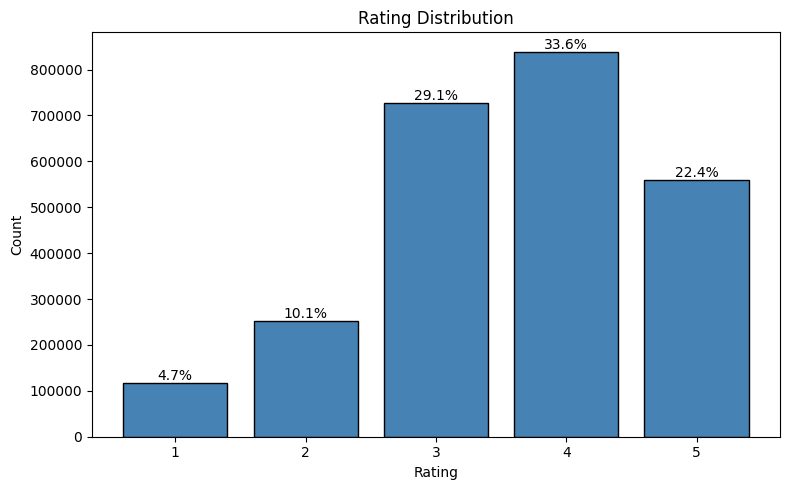

In [35]:
rating_counts = df['rating'].value_counts().sort_index()
pcts = rating_counts / len(df) * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_counts.index,
    rating_counts.values,
    color='steelblue',
    edgecolor='black'
)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

# Add percentage labels above bars
for bar, pct in zip(bars, pcts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rating_counts.index)
plt.tight_layout()
plt.show()

Rating Distribution Insights

In [36]:
avg_rating = df['rating'].mean()
median_rating = df['rating'].median()
mode_rating = df['rating'].mode()[0]

print("Rating Statistics:")
print(f"  Mean   : {avg_rating:.3f}")
print(f"  Median : {median_rating}")
print(f"  Mode   : {mode_rating}")
print(f"  Std    : {df['rating'].std():.3f}")
print()
positive = (df['rating'] >= 4).sum() / len(df) * 100
negative = (df['rating'] <= 2).sum() / len(df) * 100
neutral  = (df['rating'] == 3).sum() / len(df) * 100
print(f"Positive ratings (4-5) : {positive:.1f}%")
print(f"Neutral  ratings (3)   : {neutral:.1f}%")
print(f"Negative ratings (1-2) : {negative:.1f}%")
print()
print("INSIGHT: Ratings are left-skewed - users tend to rate movies they like.")
print("         This is common in voluntary rating systems (positivity bias).")

Rating Statistics:
  Mean   : 3.589
  Median : 4.0
  Mode   : 4
  Std    : 1.084

Positive ratings (4-5) : 56.0%
Neutral  ratings (3)   : 29.1%
Negative ratings (1-2) : 14.8%

INSIGHT: Ratings are left-skewed - users tend to rate movies they like.
         This is common in voluntary rating systems (positivity bias).


User Activity Plot

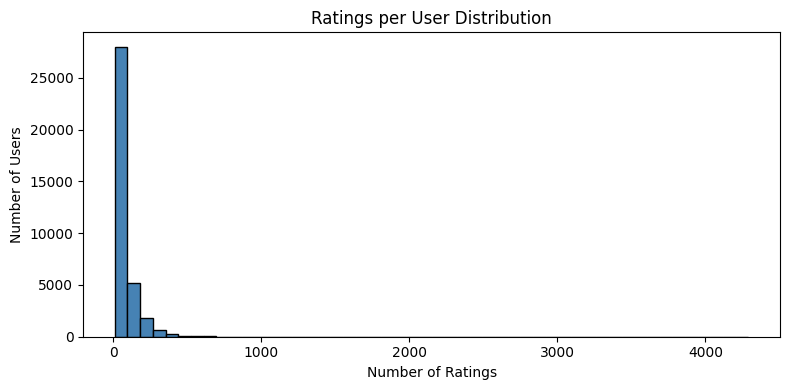

User Activity Statistics:
Min    : 10
Max    : 4,290
Mean   : 69.3
Median : 41.0
Std    : 84.2



In [37]:
ratings_per_user = df.groupby('customer_id')['rating'].count().sort_values(ascending=False)

# Distribution
plt.figure(figsize=(8, 4))
plt.hist(
    ratings_per_user.values,
    bins=50,
    color='steelblue',
    edgecolor='black'
)

plt.title('Ratings per User Distribution')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

print("User Activity Statistics:")
print(f"Min    : {ratings_per_user.min():,}")
print(f"Max    : {ratings_per_user.max():,}")
print(f"Mean   : {ratings_per_user.mean():.1f}")
print(f"Median : {ratings_per_user.median():.1f}")
print(f"Std    : {ratings_per_user.std():.1f}")
print()


User Activity Insights

In [38]:
top10_pct  = ratings_per_user.head(int(len(ratings_per_user)*0.1)).sum() / len(df) * 100
top1_pct   = ratings_per_user.head(int(len(ratings_per_user)*0.01)).sum() / len(df) * 100

print(f"Top 10% users contribute : {top10_pct:.1f}% of all ratings")
print(f"Top  1% users contribute : {top1_pct:.1f}% of all ratings")
print()
print("INSIGHT: User activity follows a power law distribution.")
print("         A small number of highly active users contribute")
print("         a disproportionately large share of all ratings.")
print("         This is the classic 80/20 rule in recommendation systems.")

Top 10% users contribute : 36.8% of all ratings
Top  1% users contribute : 7.4% of all ratings

INSIGHT: User activity follows a power law distribution.
         A small number of highly active users contribute
         a disproportionately large share of all ratings.
         This is the classic 80/20 rule in recommendation systems.


Movie Popularity Plot

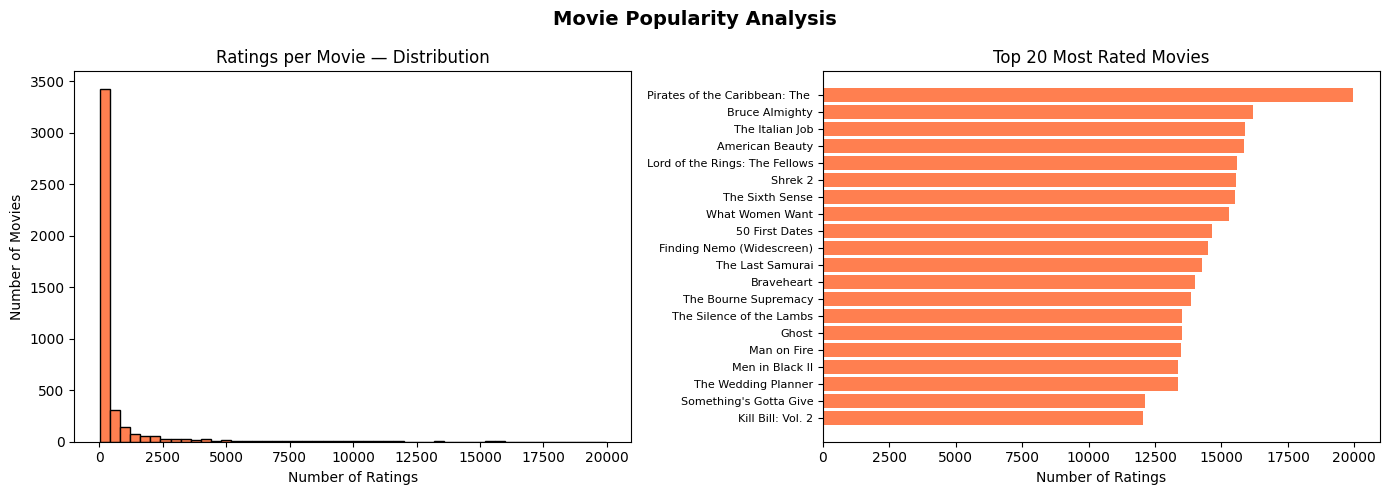

Movie Popularity Statistics:
  Min    : 10
  Max    : 19,969
  Mean   : 577.3
  Median : 63.0


In [39]:
ratings_per_movie = df.groupby('movie_id')['rating'].count().sort_values(ascending=False)

# Top 20 movies with titles
top_movies = (df.groupby(['movie_id','title'])['rating']
                .count()
                .reset_index()
                .rename(columns={'rating':'num_ratings'})
                .sort_values('num_ratings', ascending=False)
                .head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(ratings_per_movie.values, bins=50, color='coral', edgecolor='black')
axes[0].set_title('Ratings per Movie — Distribution')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')

# Top 20
axes[1].barh(range(len(top_movies)), top_movies['num_ratings'].values, color='coral')
axes[1].set_yticks(range(len(top_movies)))
axes[1].set_yticklabels([t[:30] for t in top_movies['title'].values], fontsize=8)
axes[1].set_title('Top 20 Most Rated Movies')
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.suptitle('Movie Popularity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Movie Popularity Statistics:")
print(f"  Min    : {ratings_per_movie.min():,}")
print(f"  Max    : {ratings_per_movie.max():,}")
print(f"  Mean   : {ratings_per_movie.mean():.1f}")
print(f"  Median : {ratings_per_movie.median():.1f}")

Movie Popularity Insights

In [40]:
top10_movies_pct = ratings_per_movie.head(int(len(ratings_per_movie)*0.1)).sum() / len(df) * 100
top1_movies_pct  = ratings_per_movie.head(int(len(ratings_per_movie)*0.01)).sum() / len(df) * 100

print(f"Top 10% movies receive : {top10_movies_pct:.1f}% of all ratings")
print(f"Top  1% movies receive : {top1_movies_pct:.1f}% of all ratings")
print()

# Average rating per movie
avg_rating_per_movie = df.groupby('title')['rating'].mean().sort_values(ascending=False)
print("Top 10 highest rated movies (avg):")
print(avg_rating_per_movie.head(10).to_string())
print()
print("INSIGHT: Movie popularity follows a power law — blockbusters")
print("         dominate ratings while most movies are niche titles.")
print("         This long-tail distribution is why recommendation")
print("         systems are valuable for content discovery.")

Top 10% movies receive : 75.5% of all ratings
Top  1% movies receive : 21.8% of all ratings

Top 10 highest rated movies (avg):
title
Ghost in the Shell: Stand Alone Complex: 2nd Gig        4.800000
Lost: Season 1                                          4.642450
Inu-Yasha                                               4.625000
The Simpsons: Season 6                                  4.602286
Mobile Suit Gundam SEED                                 4.539683
Inu-Yasha: The Movie 3: Swords of an Honorable Ruler    4.518987
As Time Goes By: Series 8                               4.500000
Family Guy: Freakin' Sweet Collection                   4.495069
Samurai Champloo                                        4.468421
Firefly                                                 4.460452

INSIGHT: Movie popularity follows a power law — blockbusters
         dominate ratings while most movies are niche titles.
         This long-tail distribution is why recommendation
         systems are valuable for

Sparsity Analysis

SPARSITY ANALYSIS
Users                     : 36,027
Movies                    : 4,322
Total possible ratings    : 155,708,694
Actual ratings            : 2,495,107
Sparsity                  : 98.3976%
Density                   : 1.6024%



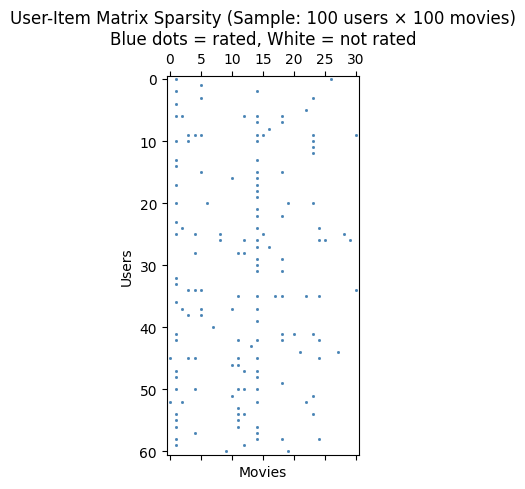

INSIGHT: The matrix is extremely sparse — most user-movie
         combinations have no rating. This is why collaborative
         filtering and matrix factorization are needed.


In [41]:
n_users   = df['customer_id'].nunique()
n_movies  = df['movie_id'].nunique()
n_ratings = len(df)
sparsity  = 1 - n_ratings / (n_users * n_movies)

print("SPARSITY ANALYSIS")
print(f"Users                     : {n_users:,}")
print(f"Movies                    : {n_movies:,}")
print(f"Total possible ratings    : {n_users * n_movies:,}")
print(f"Actual ratings            : {n_ratings:,}")
print(f"Sparsity                  : {sparsity:.4%}")
print(f"Density                   : {1-sparsity:.4%}")
print()

# Visualize sparsity on small sample
sample_users  = np.random.choice(df['customer_id'].unique(), 100, replace=False)
sample_movies = np.random.choice(df['movie_id'].unique(), 100, replace=False)
sample_df      = df[df['customer_id'].isin(sample_users) & df['movie_id'].isin(sample_movies)]

matrix_sample  = sample_df.pivot_table(index='customer_id', columns='movie_id', values='rating')

plt.figure(figsize=(12, 5))
plt.spy(matrix_sample.fillna(0), markersize=1, color='steelblue')
plt.title('User-Item Matrix Sparsity (Sample: 100 users × 100 movies)\nBlue dots = rated, White = not rated')
plt.xlabel('Movies')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

print("INSIGHT: The matrix is extremely sparse — most user-movie")
print("         combinations have no rating. This is why collaborative")
print("         filtering and matrix factorization are needed.")

Time Trends Plot

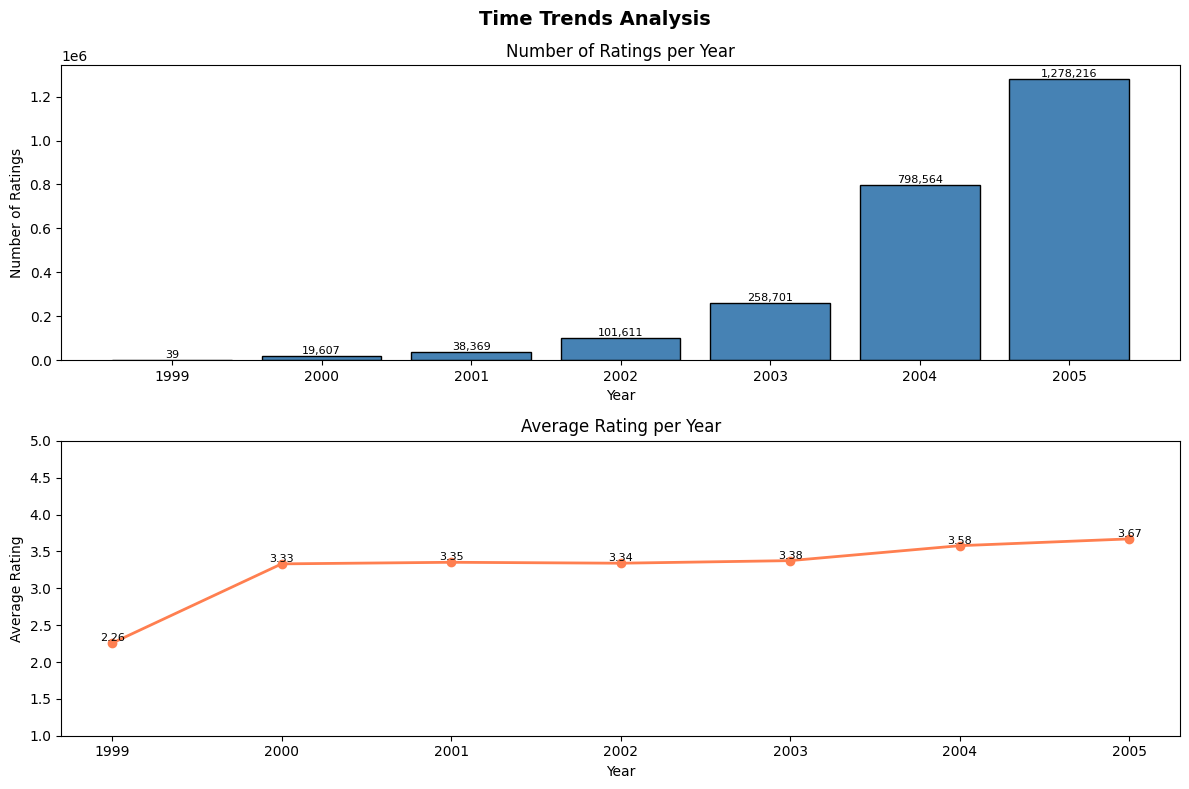

Ratings per Year:
  1999 :       39 ratings  (avg rating: 2.26)
  2000 :   19,607 ratings  (avg rating: 3.33)
  2001 :   38,369 ratings  (avg rating: 3.35)
  2002 :  101,611 ratings  (avg rating: 3.34)
  2003 :  258,701 ratings  (avg rating: 3.38)
  2004 :  798,564 ratings  (avg rating: 3.58)
  2005 : 1,278,216 ratings  (avg rating: 3.67)


In [42]:
df['year_month'] = df['date'].dt.to_period('M')
df['year_only']  = df['date'].dt.year

# Ratings per year
ratings_per_year = df.groupby('year_only')['rating'].count()

# Average rating per year
avg_rating_per_year = df.groupby('year_only')['rating'].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Volume over time
axes[0].bar(ratings_per_year.index, ratings_per_year.values, color='steelblue', edgecolor='black')
axes[0].set_title('Number of Ratings per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Ratings')
for x, y in zip(ratings_per_year.index, ratings_per_year.values):
    axes[0].text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=8)

# Avg rating over time
axes[1].plot(avg_rating_per_year.index, avg_rating_per_year.values,
             marker='o', color='coral', linewidth=2)
axes[1].set_title('Average Rating per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(1, 5)
for x, y in zip(avg_rating_per_year.index, avg_rating_per_year.values):
    axes[1].text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Time Trends Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ratings per Year:")
for yr, count in ratings_per_year.items():
    print(f"  {yr} : {count:>8,} ratings  (avg rating: {avg_rating_per_year[yr]:.2f})")

Time Trends Insights

In [43]:
peak_year    = ratings_per_year.idxmax()
peak_count   = ratings_per_year.max()
lowest_year  = ratings_per_year.idxmin()

print(f"Peak year         : {peak_year} ({peak_count:,} ratings)")
print(f"Lowest year       : {lowest_year} ({ratings_per_year.min():,} ratings)")
print(f"Growth 1999→2005  : {((ratings_per_year[2005]/ratings_per_year[1999])-1)*100:.1f}%")
print()
print("INSIGHT: Rating volume grew significantly over time, reflecting")
print("         Netflix's rapid user base expansion in early 2000s.")
print("         Average ratings remained stable suggesting consistent")
print("         user satisfaction across the platform's growth period.")

Peak year         : 2005 (1,278,216 ratings)
Lowest year       : 1999 (39 ratings)
Growth 1999→2005  : 3277376.9%

INSIGHT: Rating volume grew significantly over time, reflecting
         Netflix's rapid user base expansion in early 2000s.
         Average ratings remained stable suggesting consistent
         user satisfaction across the platform's growth period.


Rating Bias Analysis

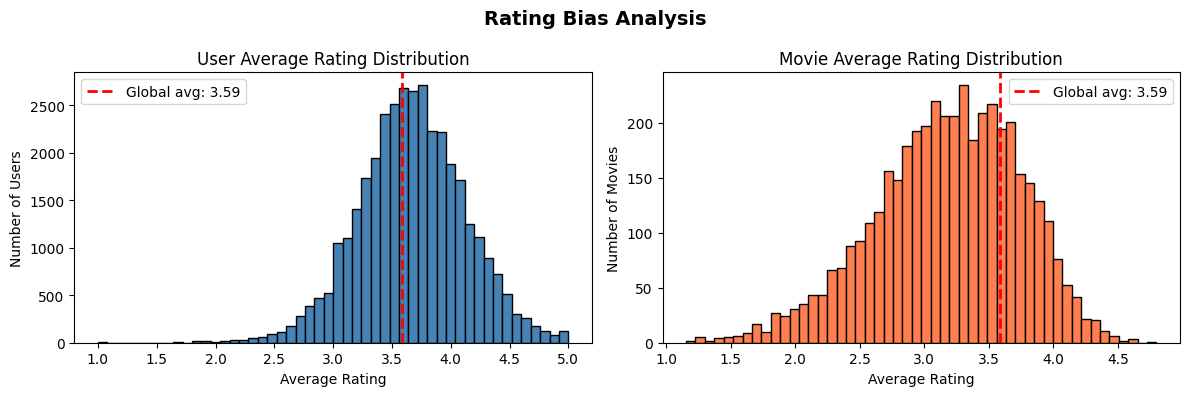

Global average rating : 3.589

User bias:
  Users who rate above global avg : 20,642 (57.3%)
  Users who rate below global avg : 15,385 (42.7%)

Movie bias:
  Movies rated above global avg : 1,095 (25.3%)
  Movies rated below global avg : 3,227 (74.7%)


In [44]:
# User bias — avg rating per user
user_avg    = df.groupby('customer_id')['rating'].mean()
global_avg  = df['rating'].mean()

# Movie bias — avg rating per movie
movie_avg   = df.groupby('movie_id')['rating'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# User bias distribution
axes[0].hist(user_avg.values, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(global_avg, color='red', linestyle='--', linewidth=2, label=f'Global avg: {global_avg:.2f}')
axes[0].set_title('User Average Rating Distribution')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# Movie bias distribution
axes[1].hist(movie_avg.values, bins=50, color='coral', edgecolor='black')
axes[1].axvline(global_avg, color='red', linestyle='--', linewidth=2, label=f'Global avg: {global_avg:.2f}')
axes[1].set_title('Movie Average Rating Distribution')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Number of Movies')
axes[1].legend()

plt.suptitle('Rating Bias Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Global average rating : {global_avg:.3f}")
print()
print("User bias:")
print(f"  Users who rate above global avg : {(user_avg > global_avg).sum():,} ({(user_avg > global_avg).mean()*100:.1f}%)")
print(f"  Users who rate below global avg : {(user_avg < global_avg).sum():,} ({(user_avg < global_avg).mean()*100:.1f}%)")
print()
print("Movie bias:")
print(f"  Movies rated above global avg : {(movie_avg > global_avg).sum():,} ({(movie_avg > global_avg).mean()*100:.1f}%)")
print(f"  Movies rated below global avg : {(movie_avg < global_avg).sum():,} ({(movie_avg < global_avg).mean()*100:.1f}%)")

Rating Bias Insights

In [45]:
lenient_users = (user_avg >= 4.0).sum()
harsh_users   = (user_avg <= 2.5).sum()

print(f"Lenient users (avg >= 4.0) : {lenient_users:,} ({lenient_users/len(user_avg)*100:.1f}%)")
print(f"Harsh users   (avg <= 2.5) : {harsh_users:,}  ({harsh_users/len(user_avg)*100:.1f}%)")
print()
print("INSIGHT: Significant user bias exists — some users consistently")
print("         rate high while others consistently rate low.")
print("         This motivates bias correction in SVD (Model 2) which")
print("         explicitly models user and item bias terms.")
print("         Item-Based CF does not account for this bias,")
print("         which is one advantage SVD has over pure CF.")

Lenient users (avg >= 4.0) : 8,548 (23.7%)
Harsh users   (avg <= 2.5) : 320  (0.9%)

INSIGHT: Significant user bias exists — some users consistently
         rate high while others consistently rate low.
         This motivates bias correction in SVD (Model 2) which
         explicitly models user and item bias terms.
         Item-Based CF does not account for this bias,
         which is one advantage SVD has over pure CF.


Business Insights

In [46]:
print("BUSINESS INSIGHTS FROM EDA")

pct_positive  = (df['rating'] >= 4).sum() / len(df) * 100
pct_neutral   = (df['rating'] == 3).sum() / len(df) * 100
pct_negative  = (df['rating'] <= 2).sum() / len(df) * 100

print()
print("""1. POSITIVITY BIAS""")
print(f" {pct_positive:.1f}% of ratings are 4 or 5 stars.")
print(f"{pct_neutral:.1f}% are neutral (3 stars).")
print(f"{pct_negative:.1f}% are negative (1-2 stars).")
print("Users only rate movies they chose to watch → selection bias.")
print("PS threshold of 3.5 is well justified — captures only")
print("genuinely positive interactions as relevant.")

print()
print("""2. POWER LAW — USERS""")
print(f"Top 10% users contribute {top10_pct:.1f}% of all ratings.")
print(f"Top  1% users contribute {top1_pct:.1f}% of all ratings.")
print("Most users are casual raters with very limited history.")
print("- Cold start problem is significant for new users.")
print("- Models must handle users with as few as 10 ratings.")

print()
print("""3. POWER LAW — MOVIES (LONG TAIL)""")
print(f"Top 10% movies receive {top10_movies_pct:.1f}% of all ratings.")
print(f"Top  1% movies receive {top1_movies_pct:.1f}% of all ratings.")
print("Majority of movies have very few ratings (long tail).")
print("- Popularity bias can dominate recommendations.")
print("- Niche content is harder to recommend accurately.")
print("- This directly motivated our min_movie_ratings=10 filter.")

print()
print("""4. RATING BIAS""")
print(f"Lenient users (avg >= 4.0) : {lenient_users:,} ({lenient_users/len(user_avg)*100:.1f}%)")
print(f"Harsh  users  (avg <= 2.5) : {harsh_users:,}  ({harsh_users/len(user_avg)*100:.1f}%)")
print("Users have systematic rating tendencies.")
print("- IBCF ignores this bias — a key weakness.")
print("- SVD explicitly models user bias and item bias terms.")
print("- This is one reason SVD outperforms IBCF in our results.")

print()
print("""5. PLATFORM GROWTH""")
print(f"Rating volume peaked in {peak_year} ({peak_count:,} ratings).")
print("Steady growth from 1999 to 2005 reflects Netflix expansion.")
print("Average rating remained stable (~3.5) across all years.")
print("- User satisfaction was consistent despite rapid growth.")
print("- More recent years have denser data → better predictions.")

print()
print("""6. SPARSITY CHALLENGE""")
print(f"Matrix sparsity       : {sparsity:.4%}")
print(f"Actual ratings        : {len(df):,}")
print(f"Possible interactions : {n_users * n_movies:,}")
print("Only 1.6% of all possible user-movie pairs are rated.")
print("- Pure similarity metrics degrade at this sparsity.")
print("- Latent factor models (SVD) handle sparsity better")
print("by learning dense representations for all users/movies.")

print()
print("These insights directly shaped our modelling decisions.")

BUSINESS INSIGHTS FROM EDA

1. POSITIVITY BIAS
 56.0% of ratings are 4 or 5 stars.
29.1% are neutral (3 stars).
14.8% are negative (1-2 stars).
Users only rate movies they chose to watch → selection bias.
PS threshold of 3.5 is well justified — captures only
genuinely positive interactions as relevant.

2. POWER LAW — USERS
Top 10% users contribute 36.8% of all ratings.
Top  1% users contribute 7.4% of all ratings.
Most users are casual raters with very limited history.
- Cold start problem is significant for new users.
- Models must handle users with as few as 10 ratings.

3. POWER LAW — MOVIES (LONG TAIL)
Top 10% movies receive 75.5% of all ratings.
Top  1% movies receive 21.8% of all ratings.
Majority of movies have very few ratings (long tail).
- Popularity bias can dominate recommendations.
- Niche content is harder to recommend accurately.
- This directly motivated our min_movie_ratings=10 filter.

4. RATING BIAS
Lenient users (avg >= 4.0) : 8,548 (23.7%)
Harsh  users  (avg <= 2.

EDA Summary

In [47]:
print("STEP 7: EDA - SUMMARY")
print(f"Total Ratings         : {len(df):,}")
print(f"Unique Users          : {df['customer_id'].nunique():,}")
print(f"Unique Movies         : {df['movie_id'].nunique():,}")
print(f"Sparsity              : {sparsity:.4%}")
print(f"Global Avg Rating     : {global_avg:.3f}")
print(f"Most Common Rating    : {df['rating'].mode()[0]} stars")
print(f"Positive Ratings(4-5) : {(df['rating']>=4).sum()/len(df)*100:.1f}%")
print(f"Peak Rating Year      : {peak_year}")
print(f"Lenient Users(avg≥4)  : {lenient_users:,}")
print(f"Harsh Users  (avg≤2.5): {harsh_users:,}")

STEP 7: EDA - SUMMARY
Total Ratings         : 2,495,107
Unique Users          : 36,027
Unique Movies         : 4,322
Sparsity              : 98.3976%
Global Avg Rating     : 3.589
Most Common Rating    : 4 stars
Positive Ratings(4-5) : 56.0%
Peak Rating Year      : 2005
Lenient Users(avg≥4)  : 8,548
Harsh Users  (avg≤2.5): 320


## 8. Train-Test Split

``` text
TRAIN-TEST SPLIT METHODOLOGY

Strategy: User-wise random 80/20 split
Seed: 42 (fully reproducible)

Procedure:
1. Group all ratings by customer_id
2. For each user, randomly sample 20% of their ratings: Test
3. Remaining 80% of each user's ratings: Train
4. Every user appears in BOTH train and test sets

Why user-wise:
- Guarantees test ratings exist for every user
- Required for per-user MAP@10 evaluation
- Prevents cold-start users in the test set

Relevance Definition (for MAP@10):
A movie is considered relevant if actual rating >= 3.5
This matches the threshold specified in the problem statement.

Data Leakage Prevention:
No (user, movie) pair appears in both train and test.
Models only see training ratings during fitting.


Perform user- wise 80/20 split

In [48]:
np.random.seed(42)

train_list = []
test_list  = []

for _, user_df in df.groupby('customer_id'):
    if len(user_df) < 2:
        train_list.append(user_df)
        continue
    n_test     = max(1, int(len(user_df) * 0.2))
    test_idx   = user_df.sample(n=n_test, random_state=42).index
    test_list.append(user_df.loc[test_idx])
    train_list.append(user_df.drop(test_idx))

train_df = pd.concat(train_list).reset_index(drop=True)
test_df  = pd.concat(test_list).reset_index(drop=True)
_ = gc.collect()

print(f"Split complete")
print(f"Train set : {len(train_df):,} ratings ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set  : {len(test_df):,} ratings  ({len(test_df)/len(df)*100:.1f}%)")

Split complete
Train set : 2,009,990 ratings (80.6%)
Test set  : 485,117 ratings  (19.4%)


Validate Split

In [49]:
train_users = set(train_df['customer_id'].unique())
test_users  = set(test_df['customer_id'].unique())
train_pairs = set(zip(train_df['customer_id'], train_df['movie_id']))
test_pairs  = set(zip(test_df['customer_id'],  test_df['movie_id']))
overlap     = train_pairs & test_pairs

print(f"Total ratings   : {len(df):,}")
print(f"Train + Test    : {len(train_df) + len(test_df):,}")
print(f"Match           : {'Yes' if len(df) == len(train_df)+len(test_df) else 'No'}")
print()
print(f"Train users     : {len(train_users):,}")
print(f"Test users      : {len(test_users):,}")
print(f"Users in both   : {len(train_users & test_users):,}")
print()
print(f"Overlapping pairs : {len(overlap):,}")
print(f"Data Leakage      : {'None' if len(overlap)==0 else 'Found'}")
print()
print("Rating distribution:")
print(f"{'Rating':<10} {'Train%':>10} {'Test%':>10}")
for r in [1,2,3,4,5]:
    tr = (train_df['rating']==r).sum()/len(train_df)*100
    te = (test_df['rating']==r).sum()/len(test_df)*100
    print(f"{r} star     {tr:>9.1f}% {te:>9.1f}%")

Total ratings   : 2,495,107
Train + Test    : 2,495,107
Match           : Yes

Train users     : 36,027
Test users      : 36,027
Users in both   : 36,027

Overlapping pairs : 0
Data Leakage      : None

Rating distribution:
Rating         Train%      Test%
1 star           4.7%       4.7%
2 star          10.1%      10.1%
3 star          29.1%      29.1%
4 star          33.6%      33.7%
5 star          22.4%      22.3%


Per User Split Statistics

In [50]:
train_per_user = train_df.groupby('customer_id')['rating'].count()
test_per_user  = test_df.groupby('customer_id')['rating'].count()

print(f"Train Users : {train_df['customer_id'].nunique():,}")
print(f"Test Users  : {test_df['customer_id'].nunique():,}")

print("\nRatings per User (Train)")
print(train_per_user.describe()[['min','50%','mean','max']])

print("\nRatings per User (Test)")
print(test_per_user.describe()[['min','50%','mean','max']])

print(f"\nUsers eligible for MAP@10 evaluation: {(test_per_user >= 1).sum():,}")

Train Users : 36,027
Test Users  : 36,027

Ratings per User (Train)
min        8.000000
50%       33.000000
mean      55.791212
max     3432.000000
Name: rating, dtype: float64

Ratings per User (Test)
min       2.000000
50%       8.000000
mean     13.465373
max     858.000000
Name: rating, dtype: float64

Users eligible for MAP@10 evaluation: 36,027


Visualize Split

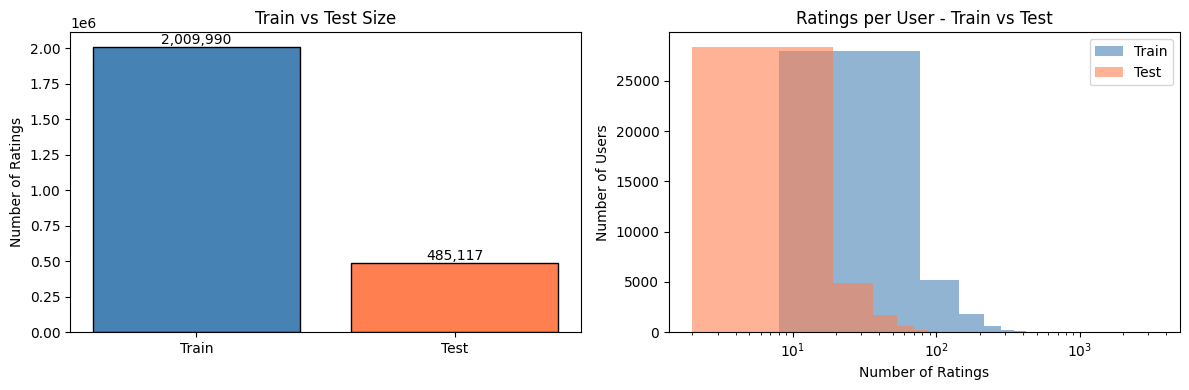

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Train', 'Test'], [len(train_df), len(test_df)],
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Train vs Test Size')
axes[0].set_ylabel('Number of Ratings')
for i, v in enumerate([len(train_df), len(test_df)]):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

axes[1].hist(train_per_user.values, bins=50, alpha=0.6, color='steelblue', label='Train')
axes[1].hist(test_per_user.values,  bins=50, alpha=0.6, color='coral',     label='Test')
axes[1].set_title('Ratings per User - Train vs Test')
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

plt.tight_layout()
plt.show()

Step 8 Summary

In [52]:
print("STEP 8: TRAIN-TEST SPLIT — SUMMARY")
print(f"Strategy          : User-wise 80/20")
print(f"Total Ratings     : {len(df):,}")
print(f"Train Ratings     : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test Ratings      : {len(test_df):,}  ({len(test_df)/len(df)*100:.1f}%)")
print(f"Train Users       : {train_df['customer_id'].nunique():,}")
print(f"Test Users        : {test_df['customer_id'].nunique():,}")
print(f"Data Leakage      : None ")
print(f"Random Seed       : 42")

STEP 8: TRAIN-TEST SPLIT — SUMMARY
Strategy          : User-wise 80/20
Total Ratings     : 2,495,107
Train Ratings     : 2,009,990 (80.6%)
Test Ratings      : 485,117  (19.4%)
Train Users       : 36,027
Test Users        : 36,027
Data Leakage      : None 
Random Seed       : 42


 ## 9. Build User-Item Matrix

 ``` text
WHAT:
  - Build a matrix where rows = users, columns = movies
  - Each cell = rating given by that user to that movie
  - Empty cells = 0 (not rated)
  - Built from TRAINING DATA ONLY

WHY:
  - Item-Based CF needs this matrix to compute similarities
  - SVD needs this matrix for factorization
  - Test data is never used here (prevents leakage)


 Build Matrix

In [53]:
from scipy.sparse import csr_matrix

# Create user and movie index mappings
user_ids  = train_df['customer_id'].unique()
movie_ids = train_df['movie_id'].unique()

user2idx  = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}
idx2user  = {i: u for u, i in user2idx.items()}
idx2movie = {i: m for m, i in movie2idx.items()}

# Map to indices
row = train_df['customer_id'].map(user2idx).values
col = train_df['movie_id'].map(movie2idx).values
val = train_df['rating'].values.astype(np.float32)

# Build sparse matrix
user_item_matrix = csr_matrix(
    (val, (row, col)),
    shape=(len(user_ids), len(movie_ids))
)

print(f"User-Item Matrix built")
print(f"Shape       : {user_item_matrix.shape}")
print(f"Users       : {user_item_matrix.shape[0]:,}")
print(f"Movies      : {user_item_matrix.shape[1]:,}")
print(f"Stored vals : {user_item_matrix.nnz:,}")
sparsity = 1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"Sparsity    : {sparsity:.4%}")

User-Item Matrix built
Shape       : (36027, 4322)
Users       : 36,027
Movies      : 4,322
Stored vals : 2,009,990
Sparsity    : 98.7091%


Verify Matrix

In [54]:
# Convert small sample to dense for verification
sample = user_item_matrix[:5, :10].toarray()

print("Sample (5 users x 10 movies):")
print(sample)
print()
print("Non-zero means rated, 0 means not rated")
print()

# Verify a specific rating
sample_row = train_df.iloc[0]
u_idx      = user2idx[sample_row['customer_id']]
m_idx      = movie2idx[sample_row['movie_id']]
matrix_val = user_item_matrix[u_idx, m_idx]

print(f"Verification check:")
print(f"  User     : {sample_row['customer_id']}")
print(f"  Movie    : {sample_row['movie_id']}")
print(f"  Actual   : {sample_row['rating']}")
print(f"  Matrix   : {matrix_val:.0f}")
print(f"  Match    : {'Yes' if sample_row['rating'] == matrix_val else 'No'}")

Sample (5 users x 10 movies):
[[3. 4. 4. 3. 2. 3. 5. 2. 4. 3.]
 [0. 4. 0. 3. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 4. 2.]]

Non-zero means rated, 0 means not rated

Verification check:
  User     : 10
  Movie    : 175
  Actual   : 3
  Matrix   : 3
  Match    : Yes


Step 9 Summary

In [55]:
sparsity = 1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])

print("STEP 9: BUILD USER-ITEM MATRIX - SUMMARY")
print(f"Matrix Shape : {user_item_matrix.shape}")
print(f"Users        : {user_item_matrix.shape[0]:,}")
print(f"Movies       : {user_item_matrix.shape[1]:,}")
print(f"Stored vals  : {user_item_matrix.nnz:,}")
print(f"Sparsity     : {sparsity:.4%}")
print(f"Format       : Sparse (CSR)")
print(f"Built from   : Training data only")
print()
print("Mappings saved:")
print(f"user2idx  : {len(user2idx):,} users")
print(f"movie2idx : {len(movie2idx):,} movies")
print(f"idx2user  : {len(idx2user):,} users")
print(f"idx2movie : {len(idx2movie):,} movies")

STEP 9: BUILD USER-ITEM MATRIX - SUMMARY
Matrix Shape : (36027, 4322)
Users        : 36,027
Movies       : 4,322
Stored vals  : 2,009,990
Sparsity     : 98.7091%
Format       : Sparse (CSR)
Built from   : Training data only

Mappings saved:
user2idx  : 36,027 users
movie2idx : 4,322 movies
idx2user  : 36,027 users
idx2movie : 4,322 movies


## 10. Baseline Model

``` text
WHAT:
  - Simplest possible model
  - Predicts the global average rating for every user-movie pair
  - No personalization: same prediction for everyone

WHY:
  - Establishes minimum performance benchmark
  - Any good model MUST beat this baseline
  - Quick sanity check on data and evaluation pipeline
  - RMSE of baseline gives reference point for Model 1 and 2


Compute Global Mean

In [56]:
global_mean = train_df['rating'].mean()

print(f"Global mean rating (from train) : {global_mean:.4f}")
print("This value will be predicted for every user-movie pair")

Global mean rating (from train) : 3.5892
This value will be predicted for every user-movie pair


Generate Predictions

In [57]:
# Predict global mean for every test rating
test_df['baseline_pred'] = global_mean

print(f"Predictions generated for {len(test_df):,} test ratings")
print(f"All predictions = {global_mean:.4f}")
print(test_df[['customer_id','movie_id','rating','baseline_pred']].head(10).to_string(index=False))

Predictions generated for 485,117 test ratings
All predictions = 3.5892
 customer_id  movie_id  rating  baseline_pred
          10      1180       3       3.589195
          10      3962       5       3.589195
          10      4306       5       3.589195
          10      3900       2       3.589195
          10      1816       2       3.589195
          10      2578       3       3.589195
          10      2518       4       3.589195
          10      2172       5       3.589195
          10      2992       4       3.589195
         169      3368       4       3.589195


Compute RMSE

In [58]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_df['rating'],
        test_df['baseline_pred']
    )
)


baseline_mae = mean_absolute_error(
    test_df['rating'],
    test_df['baseline_pred']
)

print("Baseline Model Evaluation")
print(f"Baseline RMSE : {baseline_rmse:.4f}")
print(f"Baseline MAE  : {baseline_mae:.4f}")
print()

print("Interpretation:")
print("- The model predicts the same rating for every user-movie pair.")
print("- It does not use user preferences or movie information.")
print("- It serves as a benchmark for evaluating recommendation models.")
print()

print("Goal:")
print("Any recommendation model achieving RMSE lower than this baseline")
print("is capturing useful information from user-item interactions.")

Baseline Model Evaluation
Baseline RMSE : 1.0844
Baseline MAE  : 0.9086

Interpretation:
- The model predicts the same rating for every user-movie pair.
- It does not use user preferences or movie information.
- It serves as a benchmark for evaluating recommendation models.

Goal:
Any recommendation model achieving RMSE lower than this baseline
is capturing useful information from user-item interactions.


Error Distribution Plot

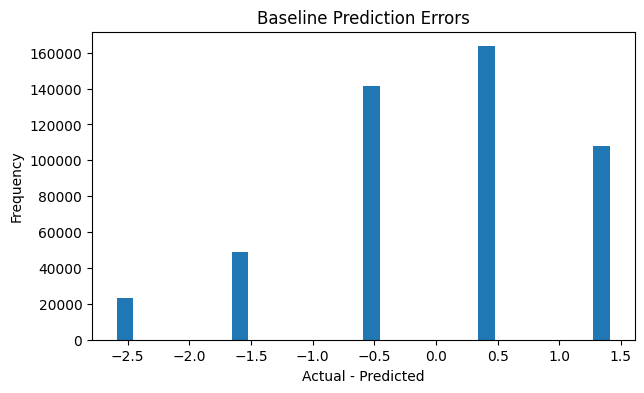

In [59]:
test_df['error'] = (
    test_df['rating']
    - test_df['baseline_pred']
)
plt.figure(figsize=(7,4))
plt.hist(test_df['error'], bins=30)
plt.title("Baseline Prediction Errors")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")
plt.show()

Step 10 Summary

In [60]:
print("STEP 10: BASELINE MODEL - SUMMARY")
print(f"Model          : Global Mean Predictor")
print(f"Global Mean    : {global_mean:.4f}")
print(f"Baseline RMSE  : {baseline_rmse:.4f}")
print()
print("Target : Both Model 1 and Model 2 must beat this RMSE")

STEP 10: BASELINE MODEL - SUMMARY
Model          : Global Mean Predictor
Global Mean    : 3.5892
Baseline RMSE  : 1.0844

Target : Both Model 1 and Model 2 must beat this RMSE


## 11. Model 1: Item-Based CF

```text
WHAT:
  - Computes similarity between movies based on user ratings
  - To predict a rating: find similar movies the user has rated
  - Weighted average of those ratings = prediction

HOW:
  - Use cosine similarity between movie vectors
  - Each movie = column in user-item matrix
  - Similar movies = movies rated similarly by same users

WHY ITEM-BASED OVER USER-BASED:
  - More stable: movies don't change preferences over time
  - Scales better: fewer movies than users
  - Works well with sparse data

Compute Item Similarity

In [61]:
from sklearn.metrics.pairwise import cosine_similarity

print("Computing item-item cosine similarity ...")
print("(This may take a few minutes ...)")

item_matrix = user_item_matrix.T  # shape: (movies, users)

item_similarity = cosine_similarity(item_matrix, dense_output=False)

print(f"Similarity matrix computed")
print(f"Shape    : {item_similarity.shape}")
print(f"Example  : similarity[0,1] = {item_similarity[0,1]:.4f}")

Computing item-item cosine similarity ...
(This may take a few minutes ...)
Similarity matrix computed
Shape    : (4322, 4322)
Example  : similarity[0,1] = 0.3723


 Predict Function

In [62]:
def predict_rating_ibcf(user_id, movie_id, n_similar=20):
    """
    Predict rating for a user-movie pair using Item-Based CF.

    Steps:
      1. Get the movie index
      2. Find top N similar movies
      3. Check which similar movies the user has rated
      4. Weighted average of those ratings
    """
    # Unknown user or movie: fallback to global mean
    if user_id not in user2idx or movie_id not in movie2idx:
        return global_mean

    u_idx = user2idx[user_id]
    m_idx = movie2idx[movie_id]

    # Get similarity scores for this movie with all others
    sim_scores = item_similarity[m_idx].toarray().flatten()
    sim_scores[m_idx] = 0

    # Get user's ratings vector
    user_ratings = user_item_matrix[u_idx].toarray().flatten()

    # Find movies the user has rated (non-zero)
    rated_mask = user_ratings > 0

    # Only keep similar movies that user has rated
    sim_rated   = sim_scores[rated_mask]
    ratings_rated = user_ratings[rated_mask]

    # Keep top N most similar
    if len(sim_rated) == 0:
        return global_mean

    top_n_idx     = np.argsort(sim_rated)[::-1][:n_similar]
    sim_top       = sim_rated[top_n_idx]
    ratings_top   = ratings_rated[top_n_idx]

    # Only use positive similarities
    pos_mask = sim_top > 0
    if pos_mask.sum() == 0:
        return global_mean

    # Weighted average
    pred = np.dot(sim_top[pos_mask], ratings_top[pos_mask]) / sim_top[pos_mask].sum()
    return round(float(pred), 4)

print("Prediction function defined")
print()
print("Testing on sample:")
sample     = test_df.iloc[0]
sample_pred = predict_rating_ibcf(sample['customer_id'], sample['movie_id'])
print(f"  User     : {sample['customer_id']}")
print(f"  Movie    : {sample['movie_id']}")
print(f"  Actual   : {sample['rating']}")
print(f"  Predicted: {sample_pred}")

Prediction function defined

Testing on sample:
  User     : 10
  Movie    : 1180
  Actual   : 3
  Predicted: 3.785


Generate All Predictions

In [63]:
print("Generating predictions for all test ratings")

test_df['ibcf_pred'] = test_df.apply(
    lambda row: predict_rating_ibcf(row['customer_id'], row['movie_id']),
    axis=1
)

print(f"Predictions generated for {len(test_df):,} test ratings")
print()
print(test_df[['customer_id','movie_id','rating','ibcf_pred']].head(10).to_string(index=False))

Generating predictions for all test ratings
Predictions generated for 485,117 test ratings

 customer_id  movie_id  rating  ibcf_pred
          10      1180       3     3.7850
          10      3962       5     3.6694
          10      4306       5     3.6717
          10      3900       2     3.4653
          10      1816       2     3.7128
          10      2578       3     3.5418
          10      2518       4     3.5332
          10      2172       5     3.6430
          10      2992       4     3.4458
         169      3368       4     3.8044


Compute RMSE

In [64]:
from sklearn.metrics import mean_squared_error

ibcf_rmse = np.sqrt(mean_squared_error(
    test_df['rating'],
    test_df['ibcf_pred']
))

print(f"Item-Based CF RMSE : {ibcf_rmse:.4f}")
print()
print("Comparison:")
print(f"Baseline RMSE      : {baseline_rmse:.4f}")
print(f"Item-Based CF RMSE : {ibcf_rmse:.4f}")
print(f"Improvement        : {baseline_rmse - ibcf_rmse:.4f}")
improvement_pct = (
    (baseline_rmse - ibcf_rmse)
    / baseline_rmse
) * 100

print(
    f"RMSE Improvement: "
    f"{improvement_pct:.2f}%"
)

Item-Based CF RMSE : 0.9561

Comparison:
Baseline RMSE      : 1.0844
Item-Based CF RMSE : 0.9561
Improvement        : 0.1283
RMSE Improvement: 11.84%


Compute MAP@10

In [65]:
"""
MAP@10 PROCEDURE:
  - For each user in test set:
    1. Get all movies in test set for that user
    2. Mark as relevant if actual rating >= 3.5 (as per PS)
    3. Rank movies by predicted rating (descending)
    4. Take top 10
    5. Compute Average Precision
  - MAP@10 = mean of all users' AP@10
"""

def average_precision_at_k(actual_relevant, predicted_ranking, k=10):
    predicted_k = predicted_ranking[:k]
    hits        = 0
    score       = 0.0
    for i, item in enumerate(predicted_k):
        if item in actual_relevant:
            hits  += 1
            score += hits / (i + 1)
    if len(actual_relevant) == 0:
        return 0.0
    return score / min(len(actual_relevant), k)


def compute_map_at_k(test_df, pred_col, k=10, threshold=3.5):
    ap_scores = []
    for user_id, user_test in test_df.groupby('customer_id'):
        # Relevant movies = actual rating >= threshold
        relevant  = set(user_test[user_test['rating'] >= threshold]['movie_id'].values)
        # Rank by predicted rating
        ranked    = user_test.sort_values(pred_col, ascending=False)['movie_id'].values
        ap        = average_precision_at_k(relevant, ranked, k)
        ap_scores.append(ap)
    return np.mean(ap_scores)


ibcf_map = compute_map_at_k(test_df, 'ibcf_pred', k=10, threshold=3.5)

print(f"Item-Based CF MAP@10 : {ibcf_map:.4f}")
print()
print(f"Relevance threshold  : >= 3.5 stars (as per PS)")
print(f"K                    : 10")

Item-Based CF MAP@10 : 0.7187

Relevance threshold  : >= 3.5 stars (as per PS)
K                    : 10


 Step 11 Summary

In [66]:
print("STEP 11: ITEM-BASED CF - SUMMARY")
print(f"Similarity Metric : Cosine Similarity")
print(f"N Similar Items   : 20")
print(f"RMSE              : {ibcf_rmse:.4f}")
print(f"MAP@10            : {ibcf_map:.4f}")
print(f"Baseline RMSE     : {baseline_rmse:.4f}")
print(f"Improvement       : {baseline_rmse - ibcf_rmse:.4f}")

STEP 11: ITEM-BASED CF - SUMMARY
Similarity Metric : Cosine Similarity
N Similar Items   : 20
RMSE              : 0.9561
MAP@10            : 0.7187
Baseline RMSE     : 1.0844
Improvement       : 0.1283


## 12. Evaluate (Item-Based CF)

``` text
METRICS:
  1. RMSE: rating prediction accuracy
  2. MAP@10: recommendation ranking quality

BOTH ALREADY COMPUTED IN STEP 11.
THIS STEP:
  - Deep dives into evaluation results
  - Error analysis
  - Prediction distribution
  - Per rating analysis

 Error Analysis

In [67]:
test_df['ibcf_error'] = test_df['rating'] - test_df['ibcf_pred']
test_df['ibcf_abs_error'] = test_df['ibcf_error'].abs()

mae = test_df['ibcf_abs_error'].mean()

print("Error Analysis:")
print(f"RMSE              : {ibcf_rmse:.4f}")
print(f"MAE               : {mae:.4f}")
print(f"Mean Error        : {test_df['ibcf_error'].mean():.4f}")
print(f"Std Error         : {test_df['ibcf_error'].std():.4f}")
print(f"Max Overpredict   : {test_df['ibcf_error'].min():.4f}")
print(f"Max Underpredict  : {test_df['ibcf_error'].max():.4f}")
print()

# Percentage of predictions within 0.5 and 1.0 stars
within_half = (test_df['ibcf_abs_error'] <= 0.5).mean() * 100
within_one  = (test_df['ibcf_abs_error'] <= 1.0).mean() * 100
print(f"Within 0.5 stars  : {within_half:.1f}%")
print(f"Within 1.0 star   : {within_one:.1f}%")

Error Analysis:
RMSE              : 0.9561
MAE               : 0.7456
Mean Error        : -0.1499
Std Error         : 0.9442
Max Overpredict   : -4.0000
Max Underpredict  : 3.7276

Within 0.5 stars  : 41.8%
Within 1.0 star   : 72.8%


Per Rating Analysis

In [68]:
print("Prediction accuracy per actual rating:")
print(f"{'Actual':>8} {'Count':>8} {'Avg Pred':>10} {'Avg Error':>10}")
print("-" * 40)

for r in [1, 2, 3, 4, 5]:
    mask     = test_df['rating'] == r
    count    = mask.sum()
    avg_pred = test_df.loc[mask, 'ibcf_pred'].mean()
    avg_err  = test_df.loc[mask, 'ibcf_abs_error'].mean()
    print(f"{r:>8} {count:>8,} {avg_pred:>10.3f} {avg_err:>10.3f}")

Prediction accuracy per actual rating:
  Actual    Count   Avg Pred  Avg Error
----------------------------------------
       1   23,024      3.128      2.128
       2   49,137      3.391      1.399
       3  141,276      3.590      0.628
       4  163,470      3.820      0.346
       5  108,210      4.089      0.911


Visualize Predictions

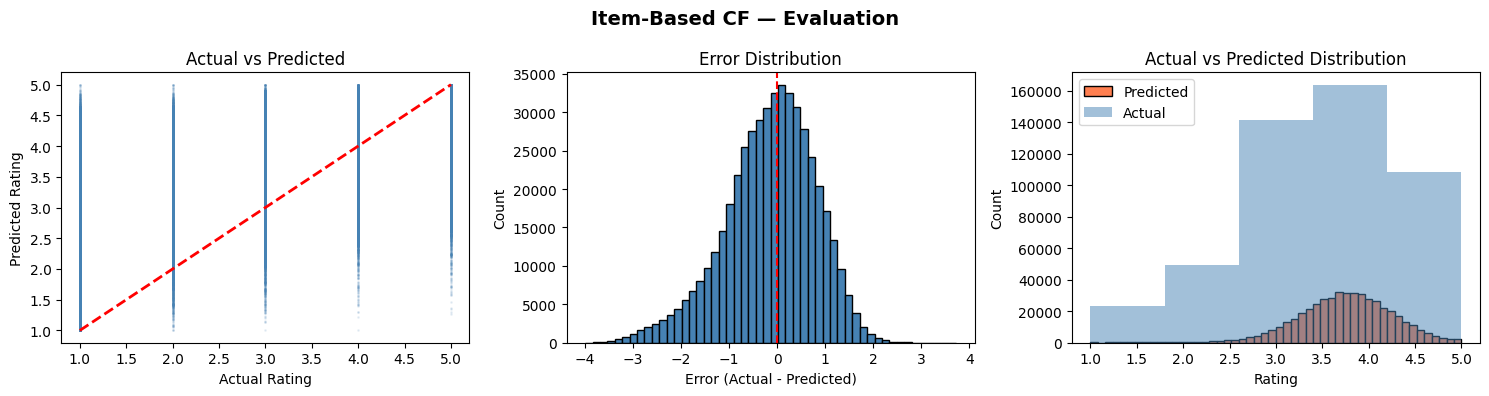

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(test_df['rating'], test_df['ibcf_pred'],
                alpha=0.1, s=1, color='steelblue')
axes[0].plot([1,5], [1,5], 'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')

# Error distribution
axes[1].hist(test_df['ibcf_error'], bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')

# Prediction distribution
axes[2].hist(test_df['ibcf_pred'], bins=50,
             color='coral', edgecolor='black', label='Predicted')
axes[2].hist(test_df['rating'],    bins=5,
             color='steelblue', alpha=0.5, label='Actual')
axes[2].set_title('Actual vs Predicted Distribution')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Item-Based CF — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

MAP@10 Deep Dive

MAP@10 Deep Dive:
  MAP@10                    : 0.7187
  Median AP                 : 0.7862
  Users with relevant items : 34,525
  Users with no relevant    : 1,502
  Users with AP = 0         : 1,520
  Users with AP = 1         : 10,633



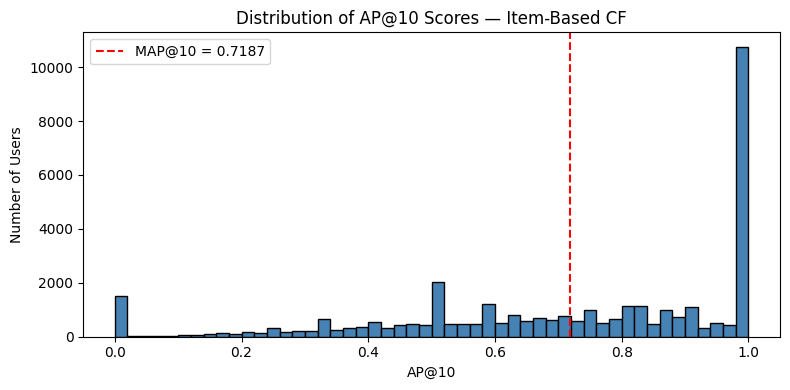

In [70]:
ap_scores = []
users_with_relevant = 0
users_no_relevant   = 0

for user_id, user_test in test_df.groupby('customer_id'):
    relevant = set(user_test[user_test['rating'] >= 3.5]['movie_id'].values)
    ranked   = user_test.sort_values('ibcf_pred', ascending=False)['movie_id'].values
    ap       = average_precision_at_k(relevant, ranked, k=10)
    ap_scores.append(ap)
    if len(relevant) > 0:
        users_with_relevant += 1
    else:
        users_no_relevant += 1

ap_scores = np.array(ap_scores)

print(f"MAP@10 Deep Dive:")
print(f"  MAP@10                    : {ap_scores.mean():.4f}")
print(f"  Median AP                 : {np.median(ap_scores):.4f}")
print(f"  Users with relevant items : {users_with_relevant:,}")
print(f"  Users with no relevant    : {users_no_relevant:,}")
print(f"  Users with AP = 0         : {(ap_scores == 0).sum():,}")
print(f"  Users with AP = 1         : {(ap_scores == 1).sum():,}")
print()

# Distribution of AP scores
plt.figure(figsize=(8, 4))
plt.hist(ap_scores, bins=50, color='steelblue', edgecolor='black')
plt.axvline(ap_scores.mean(), color='red', linestyle='--',
            label=f'MAP@10 = {ap_scores.mean():.4f}')
plt.title('Distribution of AP@10 Scores — Item-Based CF')
plt.xlabel('AP@10')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

Step 12 Summary

In [71]:
print("STEP 12: EVALUATE ITEM-BASED CF - SUMMARY")
print(f"RMSE              : {ibcf_rmse:.4f}")
print(f"MAE               : {mae:.4f}")
print(f"MAP@10            : {ibcf_map:.4f}")
print(f"Within 0.5 stars  : {within_half:.1f}%")
print(f"Within 1.0 star   : {within_one:.1f}%")
print(f"Baseline RMSE     : {baseline_rmse:.4f}")
print(f"Improvement       : {baseline_rmse - ibcf_rmse:.4f}")

STEP 12: EVALUATE ITEM-BASED CF - SUMMARY
RMSE              : 0.9561
MAE               : 0.7456
MAP@10            : 0.7187
Within 0.5 stars  : 41.8%
Within 1.0 star   : 72.8%
Baseline RMSE     : 1.0844
Improvement       : 0.1283


## 13. Top-10 Recommendations (Item-Based CF)

``` text
WHAT:
  - For a given user generate top 10 movie recommendations
  - Only recommend movies the user has NOT yet rated
  - Rank by predicted rating (descending)
  - Show movie title and predicted score

PROCEDURE:
  1. Get all movies user has NOT rated in training set
  2. Predict rating for each unrated movie
  3. Sort by predicted rating
  4. Return top 10

Recommendation Function

In [72]:
def get_top10_ibcf(user_id, n=10):
    """
    Generate top-N recommendations for a user using Item-Based CF.
    Only recommends movies not already rated by the user.
    """
    if user_id not in user2idx:
        print(f"User {user_id} not in training set")
        return None

    u_idx = user2idx[user_id]

    # Movies already rated by user in training
    rated_movies = set(train_df[train_df['customer_id'] == user_id]['movie_id'].values)

    # All movies in training set
    all_movies   = set(movie2idx.keys())

    # Unrated movies
    unrated      = all_movies - rated_movies

    # Predict rating for each unrated movie
    predictions  = []
    for movie_id in unrated:
        pred = predict_rating_ibcf(user_id, movie_id)
        predictions.append((movie_id, pred))

    # Sort by predicted rating
    predictions  = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

    # Build result DataFrame
    results = pd.DataFrame(predictions, columns=['movie_id', 'predicted_rating'])
    results = results.merge(
        movies_raw[['movie_id', 'title', 'year']],
        on='movie_id', how='left'
    )
    results.index = range(1, len(results)+1)
    return results[['title', 'year', 'predicted_rating']]

print("Recommendation function defined")

Recommendation function defined


Generate Recommendations for Sample Users

In [73]:
# Pick 3 random sample users
sample_users = train_df['customer_id'].drop_duplicates().sample(
    3,
    random_state=42
)

for user_id in sample_users:
    print(f"Top-10 Recommendations for User {user_id}:")
    print("-" * 55)
    recs = get_top10_ibcf(user_id)
    if recs is not None:
        print(recs.to_string())
    print()

Top-10 Recommendations for User 928463:
-------------------------------------------------------
                          title    year  predicted_rating
1               Up at the Villa  2000.0            4.1635
2                   Cry Freedom  1987.0            4.1040
3     Sharpe 5: Sharpe's Honour  1994.0            4.0795
4              The Four Seasons  1981.0            4.0593
5   Sharpe 9: Sharpe's Regiment  1996.0            4.0448
6              The Great Gatsby  2000.0            4.0382
7                    Local Hero  1983.0            4.0301
8            A Farewell to Arms  1932.0            4.0076
9                     Choose Me  1983.0            3.9927
10            Woman of the Year  1942.0            3.9892

Top-10 Recommendations for User 2564767:
-------------------------------------------------------
                                                                          title    year  predicted_rating
1                  The Living Edens: The Lost World: Venezuela

In [74]:
print("Observations:")
print("- Recommended movies are not present in the user's training history.")
print("- Movies are ranked by predicted rating.")
print("- Recommendations are personalized using item similarity.")

Observations:
- Recommended movies are not present in the user's training history.
- Movies are ranked by predicted rating.
- Recommendations are personalized using item similarity.


Show User History

In [75]:
focus_user = train_df['customer_id'].unique()[0]

# User's rating history — train_df already has title and year
user_history = (train_df[train_df['customer_id'] == focus_user]
                .sort_values('rating', ascending=False)
                [['title', 'year', 'rating']]
                .head(10)
                .reset_index(drop=True))

user_history.index = range(1, len(user_history)+1)

print(f"User {focus_user} — Top Rated Movies (History):")
print(user_history.to_string())
print()

print(f"User {focus_user} — Top-10 Recommendations:")
recs = get_top10_ibcf(focus_user)
print(recs.to_string())

User 10 — Top Rated Movies (History):
                                                     title  year  rating
1                                                The Mummy  1999       5
2                                                    Signs  2002       5
3   Pirates of the Caribbean: The Curse of the Black Pearl  2003       5
4                                        Princess Mononoke  1997       5
5                                              Whale Rider  2003       5
6                                     Sleepless in Seattle  1993       5
7                                                  Titanic  1953       5
8                                    Bowling for Columbine  2002       4
9                                     Being John Malkovich  1999       4
10                                         What Women Want  2000       4

User 10 — Top-10 Recommendations:
                                 title    year  predicted_rating
1                        The Wanderers  1995.0            4

Step 13 Summary

In [76]:
print("STEP 13: TOP-10 RECOMMENDATIONS - SUMMARY")
print(f"Model             : Item-Based CF")
print(f"Similarity Metric : Cosine Similarity")
print(f"N Similar Items   : 20")
print(f"Recommendation    : Unrated movies only")
print(f"Ranking           : By predicted rating (desc)")

STEP 13: TOP-10 RECOMMENDATIONS - SUMMARY
Model             : Item-Based CF
Similarity Metric : Cosine Similarity
N Similar Items   : 20
Recommendation    : Unrated movies only
Ranking           : By predicted rating (desc)


## 14. Success & Failure Cases (Item-Based CF)

``` text
WHAT:
  - Analyze where Item-Based CF works well (success cases)
  - Analyze where it fails (failure cases)
  - Understand WHY it succeeds and fails
  - These insights directly justify why we need Model 2 (SVD)


Success Cases

In [77]:
success_cases = (test_df[test_df['ibcf_abs_error'] <= 0.5]
                 .sort_values('ibcf_abs_error')
                 [['customer_id','title','year','rating','ibcf_pred','ibcf_abs_error']]
                 .head(10)
                 .reset_index(drop=True))

success_cases.index = range(1, len(success_cases)+1)

print(f"Success Cases (absolute error <= 0.5):")
print(f"Total : {(test_df['ibcf_abs_error'] <= 0.5).sum():,} ({(test_df['ibcf_abs_error'] <= 0.5).mean()*100:.1f}%)")
print()
print(success_cases.to_string())
print()
print("POSSIBLE REASONS FOR SUCCESS:")
print("  - User has rated many similar movies")
print("  - Movie has many ratings: strong similarity signal")
print("  - User preferences align with popular taste")

Success Cases (absolute error <= 0.5):
Total : 202,610 (41.8%)

    customer_id                                        title  year  rating  ibcf_pred  ibcf_abs_error
1        915726                         Nero Wolfe: Season 2  2002       5        5.0             0.0
2        481064  101 Dalmatians II: Patch's London Adventure  2003       5        5.0             0.0
3        481064                                   Flatliners  1990       5        5.0             0.0
4       2270619                               Chain Reaction  1996       5        5.0             0.0
5       2270619               Farscape: The Peacekeeper Wars  2004       5        5.0             0.0
6        497102                           The Color of Money  1986       5        5.0             0.0
7       1793702                                  Rush Hour 2  2001       5        5.0             0.0
8        651230            Cadfael: A Morbid Taste for Bones  1996       1        1.0             0.0
9        651230   

Failure Cases

In [78]:
failure_cases = (test_df[test_df['ibcf_abs_error'] >= 2.0]
                 .sort_values('ibcf_abs_error', ascending=False)
                 [['customer_id','title','year','rating','ibcf_pred','ibcf_abs_error']]
                 .head(10)
                 .reset_index(drop=True))

failure_cases.index = range(1, len(failure_cases)+1)

print(f"Failure Cases (absolute error >= 2.0):")
print(f"Total : {(test_df['ibcf_abs_error'] >= 2.0).sum():,} ({(test_df['ibcf_abs_error'] >= 2.0).mean()*100:.1f}%)")
print()
print(failure_cases.to_string())
print()
print("POSSIBLE REASONS FOR FAILURE:")
print("  - Movie has very few ratings: weak similarity signal")
print("  - User has unique/niche preferences")
print("  - User rating bias not accounted for")
print("  - Sparse neighborhood: fallback to global mean")

Failure Cases (absolute error >= 2.0):
Total : 21,141 (4.4%)

    customer_id                    title  year  rating  ibcf_pred  ibcf_abs_error
1       1354943       Shaft's Big Score!  1972       1     5.0000          4.0000
2        180621      Duplex (Widescreen)  2003       1     5.0000          4.0000
3       2407493           Leonard Part 6  1987       1     5.0000          4.0000
4       2176953               Borderline  2002       1     5.0000          4.0000
5       1222397          Rosemary's Baby  1968       1     5.0000          4.0000
6        727301    Bringing Out the Dead  1999       1     4.9559          3.9559
7       1265312  The Matrix: Revolutions  2003       1     4.9541          3.9541
8       1325639                  Beaches  1988       1     4.9272          3.9272
9        611076        Kill Bill: Vol. 2  2004       1     4.9119          3.9119
10      1474603              The Village  2004       1     4.9057          3.9057

POSSIBLE REASONS FOR FAILURE:
  - M

Success vs Failure Analysis

In [79]:
# Check if failures are related to movie popularity
test_df['movie_rating_count'] = test_df['movie_id'].map(
    train_df.groupby('movie_id')['rating'].count()
)
test_df['user_rating_count'] = test_df['customer_id'].map(
    train_df.groupby('customer_id')['rating'].count()
)

# Success group
success_mask = test_df['ibcf_abs_error'] <= 0.5
failure_mask = test_df['ibcf_abs_error'] >= 2.0

print("Movie popularity in success vs failure cases:")
print(f"  Avg movie ratings (success) : {test_df.loc[success_mask,'movie_rating_count'].mean():.0f}")
print(f"  Avg movie ratings (failure) : {test_df.loc[failure_mask,'movie_rating_count'].mean():.0f}")
print()
print("User activity in success vs failure cases:")
print(f"  Avg user ratings (success)  : {test_df.loc[success_mask,'user_rating_count'].mean():.0f}")
print(f"  Avg user ratings (failure)  : {test_df.loc[failure_mask,'user_rating_count'].mean():.0f}")
print()
print("INSIGHT: More popular movies and more active users")
print("         lead to better Item-Based CF predictions.")
print("         This is a known limitation of CF methods.")

Movie popularity in success vs failure cases:
  Avg movie ratings (success) : 4301
  Avg movie ratings (failure) : 4005

User activity in success vs failure cases:
  Avg user ratings (success)  : 145
  Avg user ratings (failure)  : 126

INSIGHT: More popular movies and more active users
         lead to better Item-Based CF predictions.
         This is a known limitation of CF methods.


In [80]:
print("Key Observation:")
print("Item-Based CF performs best when users and movies")
print("have sufficient interaction history. Performance")
print("degrades for sparse users and less popular movies.")

Key Observation:
Item-Based CF performs best when users and movies
have sufficient interaction history. Performance
degrades for sparse users and less popular movies.


Visualize Success vs Failure

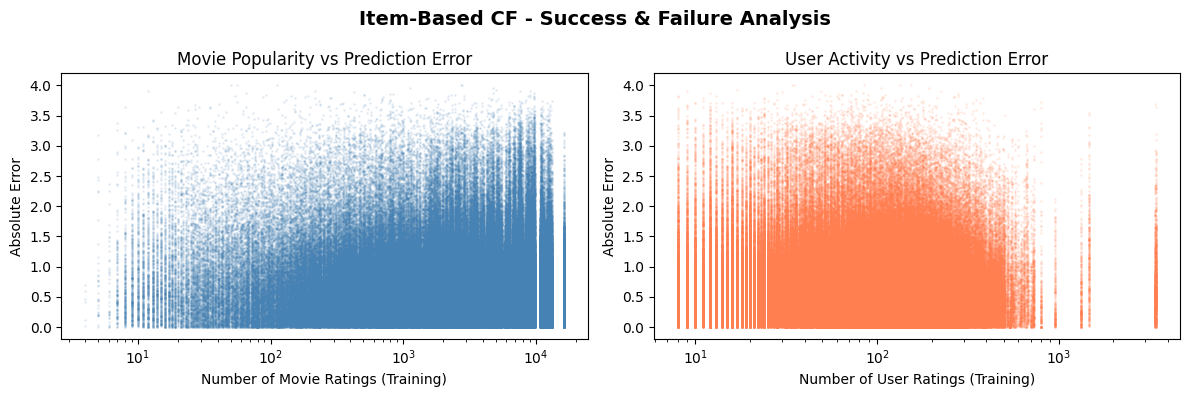

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Movie popularity vs error
axes[0].scatter(test_df['movie_rating_count'],
                test_df['ibcf_abs_error'],
                alpha=0.1, s=1, color='steelblue')
axes[0].set_title('Movie Popularity vs Prediction Error')
axes[0].set_xlabel('Number of Movie Ratings (Training)')
axes[0].set_ylabel('Absolute Error')
axes[0].set_xscale('log')

# User activity vs error
axes[1].scatter(test_df['user_rating_count'],
                test_df['ibcf_abs_error'],
                alpha=0.1, s=1, color='coral')
axes[1].set_title('User Activity vs Prediction Error')
axes[1].set_xlabel('Number of User Ratings (Training)')
axes[1].set_ylabel('Absolute Error')
axes[1].set_xscale('log')

plt.suptitle('Item-Based CF - Success & Failure Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [82]:
improvement_pct = (
    (baseline_rmse - ibcf_rmse)
    / baseline_rmse
) * 100

print(f"RMSE Improvement over Baseline : {improvement_pct:.2f}%")

RMSE Improvement over Baseline : 11.84%


Step 14 Summary

In [83]:
print("STEP 14: SUCCESS & FAILURE CASES - SUMMARY")
print()
print("SUCCESS CASES:")
print(f"  Predictions within 0.5 stars : {(test_df['ibcf_abs_error']<=0.5).sum():,} ({(test_df['ibcf_abs_error']<=0.5).mean()*100:.1f}%)")
print(f"  Predictions within 1.0 star  : {(test_df['ibcf_abs_error']<=1.0).sum():,} ({(test_df['ibcf_abs_error']<=1.0).mean()*100:.1f}%)")
print()
print("FAILURE CASES:")
print(f"  Predictions off by >= 2 stars : {(test_df['ibcf_abs_error']>=2.0).sum():,} ({(test_df['ibcf_abs_error']>=2.0).mean()*100:.1f}%)")
print()
print("KEY LIMITATIONS OF ITEM-BASED CF:")
print("  1. No user bias correction")
print("  2. Struggles with sparse movies")
print("  3. Popularity bias — better for popular movies")
print("  4. Cannot capture latent user preferences")
print()
print("These limitations motivate Model 2 - SVD")


STEP 14: SUCCESS & FAILURE CASES - SUMMARY

SUCCESS CASES:
  Predictions within 0.5 stars : 202,610 (41.8%)
  Predictions within 1.0 star  : 353,094 (72.8%)

FAILURE CASES:
  Predictions off by >= 2 stars : 21,141 (4.4%)

KEY LIMITATIONS OF ITEM-BASED CF:
  1. No user bias correction
  2. Struggles with sparse movies
  3. Popularity bias — better for popular movies
  4. Cannot capture latent user preferences

These limitations motivate Model 2 - SVD


## 15. SVD Model

``` text
WHAT:
  - SVD decomposes user-item matrix into latent factors
  - Learns hidden patterns in user preferences
  - Explicitly models user bias and item bias
  - Much better at handling sparse data than CF

WHY SVD OVER ITEM-BASED CF:
  - Handles user bias (harsh vs lenient raters)
  - Captures latent preferences (genres, themes)
  - Better generalization on sparse data
  - Industry standard for recommendation systems

LIBRARY: Surprise (scikit-surprise)
  - Purpose built for recommendation systems
  - Clean train/test interface
  - Built-in SVD with bias terms

Prepare Data for Surprise Library

In [84]:
from surprise import SVD, Dataset, Reader

# Surprise needs ratings in scale 1-5
reader = Reader(rating_scale=(1, 5))

# Load training data into Surprise format
train_surprise = Dataset.load_from_df(
    train_df[['customer_id', 'movie_id', 'rating']],
    reader
).build_full_trainset()

print(f"Training data loaded into Surprise format")
print(f"Users  : {train_surprise.n_users:,}")
print(f"Movies : {train_surprise.n_items:,}")
print(f"Ratings: {train_surprise.n_ratings:,}")

Training data loaded into Surprise format
Users  : 36,027
Movies : 4,322
Ratings: 2,009,990


Tuning SVD Model

In [85]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [75, 100, 125],
    'n_epochs' : [15, 20],
    'reg_all'  : [0.02, 0.05]
}

print("Running hyperparameter tuning (12 combinations, 2-fold CV)...")

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=2, n_jobs=-1)
gs.fit(Dataset.load_from_df(
    train_df[['customer_id', 'movie_id', 'rating']],
    Reader(rating_scale=(1,5))
))

best_params = gs.best_params['rmse']
best_rmse   = gs.best_score['rmse']

print(f"Best Params : {best_params}")
print(f"Best RMSE   : {best_rmse:.4f}")

Running hyperparameter tuning (12 combinations, 2-fold CV)...
Best Params : {'n_factors': 125, 'n_epochs': 20, 'reg_all': 0.05}
Best RMSE   : 0.9244


Train SVD Model

In [86]:
import time

print("Training SVD model ...")

svd_model = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    reg_all=best_params['reg_all'],
    lr_all=0.005,
    random_state=42
)

start = time.time()
svd_model.fit(train_surprise)
svd_train_time = time.time() - start

print(f"SVD model trained")
print(f"Latent Factors : {best_params['n_factors']}")
print(f"Epochs         : {best_params['n_epochs']}")
print(f"Learning Rate  : 0.005")
print(f"Regularization : {best_params['reg_all']}")
print(f"(Parameters selected via GridSearchCV hyperparameter tuning)")

Training SVD model ...
SVD model trained
Latent Factors : 125
Epochs         : 20
Learning Rate  : 0.005
Regularization : 0.05
(Parameters selected via GridSearchCV hyperparameter tuning)


Training Time

In [87]:
print(f"Training Time : {svd_train_time:.2f} sec")

Training Time : 21.31 sec


Generate Predictions

In [88]:
print("Generating predictions ...")

test_df['svd_pred'] = test_df.apply(
    lambda row: svd_model.predict(
        row['customer_id'],
        row['movie_id']
    ).est,
    axis=1
)

print(f"Predictions generated for {len(test_df):,} test ratings")
print()
print(test_df[['customer_id','movie_id','rating','svd_pred']].head(10).to_string(index=False))

Generating predictions ...
Predictions generated for 485,117 test ratings

 customer_id  movie_id  rating  svd_pred
          10      1180       3  3.650127
          10      3962       5  4.141801
          10      4306       5  4.110072
          10      3900       2  3.417793
          10      1816       2  2.149591
          10      2578       3  3.144848
          10      2518       4  2.891285
          10      2172       5  3.857454
          10      2992       4  3.286736
         169      3368       4  3.652936


Error Analysis

In [89]:
test_df['svd_error']     = test_df['rating'] - test_df['svd_pred']
test_df['svd_abs_error'] = test_df['svd_error'].abs()
svd_rmse = np.sqrt(mean_squared_error(
    test_df['rating'],
    test_df['svd_pred']
))

svd_mae      = test_df['svd_abs_error'].mean()
within_half  = (test_df['svd_abs_error'] <= 0.5).mean() * 100
within_one   = (test_df['svd_abs_error'] <= 1.0).mean() * 100

print("SVD Error Analysis:")
print(f"  RMSE             : {svd_rmse:.4f}")
print(f"  MAE              : {svd_mae:.4f}")
print(f"  Mean Error       : {test_df['svd_error'].mean():.4f}")
print(f"  Std Error        : {test_df['svd_error'].std():.4f}")
print(f"  Within 0.5 stars : {within_half:.1f}%")
print(f"  Within 1.0 star  : {within_one:.1f}%")
print()
print("Per rating analysis:")
print(f"{'Actual':>8} {'Count':>8} {'Avg Pred':>10} {'Avg Error':>10}")
print("-" * 40)
for r in [1,2,3,4,5]:
    mask     = test_df['rating'] == r
    count    = mask.sum()
    avg_pred = test_df.loc[mask, 'svd_pred'].mean()
    avg_err  = test_df.loc[mask, 'svd_abs_error'].mean()
    print(f"{r:>8} {count:>8,} {avg_pred:>10.3f} {avg_err:>10.3f}")

SVD Error Analysis:
  RMSE             : 0.8938
  MAE              : 0.7007
  Mean Error       : -0.0033
  Std Error        : 0.8938
  Within 0.5 stars : 43.9%
  Within 1.0 star  : 75.3%

Per rating analysis:
  Actual    Count   Avg Pred  Avg Error
----------------------------------------
       1   23,024      2.889      1.889
       2   49,137      3.121      1.132
       3  141,276      3.388      0.492
       4  163,470      3.702      0.417
       5  108,210      4.047      0.953


Visualize SVD Predictions

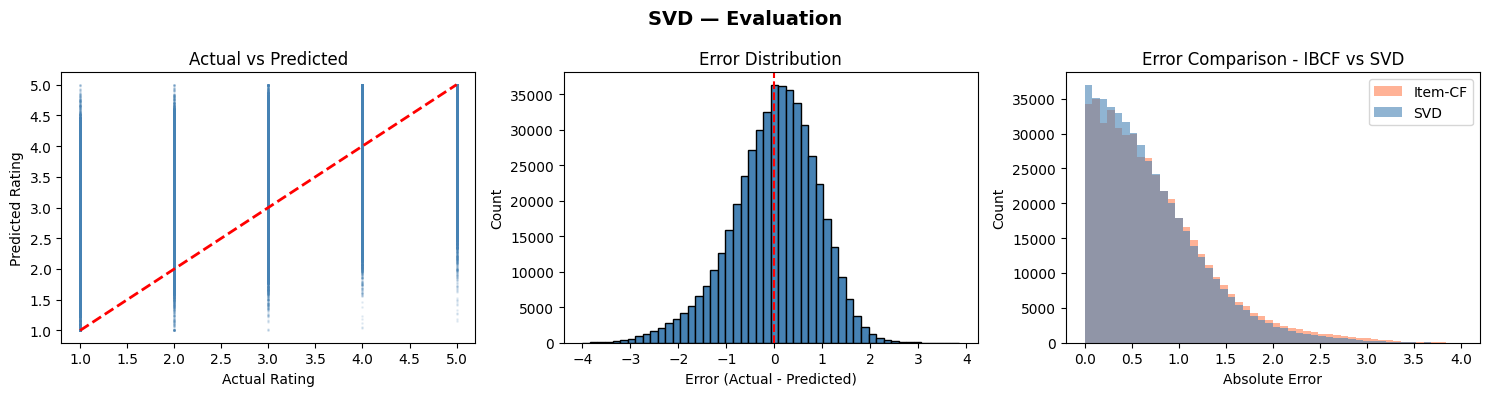

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(test_df['rating'], test_df['svd_pred'],
                alpha=0.1, s=1, color='steelblue')
axes[0].plot([1,5], [1,5], 'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')

# Error distribution
axes[1].hist(test_df['svd_error'], bins=50,
             color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Error Distribution')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Count')

# Compare IBCF vs SVD error
axes[2].hist(test_df['ibcf_abs_error'], bins=50, alpha=0.6,
             color='coral',     label='Item-CF')
axes[2].hist(test_df['svd_abs_error'],  bins=50, alpha=0.6,
             color='steelblue', label='SVD')
axes[2].set_title('Error Comparison - IBCF vs SVD')
axes[2].set_xlabel('Absolute Error')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('SVD — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Step 15 Summary

In [91]:
print("STEP 15: SVD MODEL - SUMMARY")

print(f"Latent Factors : {best_params['n_factors']}")
print(f"Epochs         : {best_params['n_epochs']}")
print(f"Learning Rate  : 0.005")
print(f"Regularization : {best_params['reg_all']}")
print(f"(Parameters selected via GridSearchCV hyperparameter tuning)")

STEP 15: SVD MODEL - SUMMARY
Latent Factors : 125
Epochs         : 20
Learning Rate  : 0.005
Regularization : 0.05
(Parameters selected via GridSearchCV hyperparameter tuning)


## 16. Evaluate SVD

``` text
METRICS:
  1. RMSE  - rating prediction accuracy
  2. MAP@10 - recommendation ranking quality

BOTH ALREADY COMPUTED IN STEP 15.
THIS STEP:
  - Deep dive into SVD evaluation results
  - Compare SVD vs Item-Based CF in detail
  - Understand where SVD improves and where it still fails


Compute RMSE

In [92]:
svd_rmse = np.sqrt(mean_squared_error(
    test_df['rating'],
    test_df['svd_pred']
))

print("RMSE Comparison:")
print(f"Baseline RMSE      : {baseline_rmse:.4f}")
print(f"Item-Based CF RMSE : {ibcf_rmse:.4f}")
print(f"SVD RMSE           : {svd_rmse:.4f}")
print()
print(f"SVD vs Baseline    : {baseline_rmse - svd_rmse:.4f} improvement")
print(f"SVD vs IBCF        : {ibcf_rmse - svd_rmse:.4f} improvement")

RMSE Comparison:
Baseline RMSE      : 1.0844
Item-Based CF RMSE : 0.9561
SVD RMSE           : 0.8938

SVD vs Baseline    : 0.1906 improvement
SVD vs IBCF        : 0.0622 improvement


Compute MAP@10

In [93]:
svd_map = compute_map_at_k(test_df, 'svd_pred', k=10, threshold=3.5)

print("MAP@10 Comparison:")
print(f"Item-Based CF MAP@10 : {ibcf_map:.4f}")
print(f"SVD MAP@10           : {svd_map:.4f}")
print(f"Improvement          : {svd_map - ibcf_map:.4f}")
print()
print(f"Relevance threshold  : >= 3.5 stars (as per PS)")
print(f"K                    : 10")

MAP@10 Comparison:
Item-Based CF MAP@10 : 0.7187
SVD MAP@10           : 0.7627
Improvement          : 0.0440

Relevance threshold  : >= 3.5 stars (as per PS)
K                    : 10


Full Metrics Comparison

In [94]:
svd_mae      = test_df['svd_abs_error'].mean()

print("FULL EVALUATION COMPARISON")
print(f"{'Metric':<20} {'Baseline':>10} {'IBCF':>10} {'SVD':>10}")
print("-" * 55)
print(f"{'RMSE':<20} {baseline_rmse:>10.4f} {ibcf_rmse:>10.4f} {svd_rmse:>10.4f}")
print(f"{'MAE':<20} {baseline_mae:>10.4f} {mae:>10.4f} {svd_mae:>10.4f}")
print(f"{'MAP@10':<20} {'N/A':>10} {ibcf_map:>10.4f} {svd_map:>10.4f}")
print(f"{'Within 0.5 stars':<20} {'N/A':>10} {(test_df['ibcf_abs_error']<=0.5).mean()*100:>9.1f}% {(test_df['svd_abs_error']<=0.5).mean()*100:>9.1f}%")
print(f"{'Within 1.0 star':<20} {'N/A':>10} {(test_df['ibcf_abs_error']<=1.0).mean()*100:>9.1f}% {(test_df['svd_abs_error']<=1.0).mean()*100:>9.1f}%")
print()

FULL EVALUATION COMPARISON
Metric                 Baseline       IBCF        SVD
-------------------------------------------------------
RMSE                     1.0844     0.9561     0.8938
MAE                      0.9086     0.7456     0.7007
MAP@10                      N/A     0.7187     0.7627
Within 0.5 stars            N/A      41.8%      43.9%
Within 1.0 star             N/A      72.8%      75.3%



Per Rating Comparison

In [95]:
print("Per Rating Absolute Error - IBCF vs SVD:")
print(f"{'Actual':>8} {'Count':>8} {'IBCF Error':>12} {'SVD Error':>12} {'Winner':>8}")
print("-" * 55)

for r in [1, 2, 3, 4, 5]:
    mask      = test_df['rating'] == r
    count     = mask.sum()
    ibcf_err  = test_df.loc[mask, 'ibcf_abs_error'].mean()
    svd_err   = test_df.loc[mask, 'svd_abs_error'].mean()
    winner    = 'SVD' if svd_err < ibcf_err else 'IBCF'
    print(f"{r:>8} {count:>8,} {ibcf_err:>12.3f} {svd_err:>12.3f} {winner:>8}")

Per Rating Absolute Error - IBCF vs SVD:
  Actual    Count   IBCF Error    SVD Error   Winner
-------------------------------------------------------
       1   23,024        2.128        1.889      SVD
       2   49,137        1.399        1.132      SVD
       3  141,276        0.628        0.492      SVD
       4  163,470        0.346        0.417     IBCF
       5  108,210        0.911        0.953     IBCF


MAP@10 Deep Dive

In [96]:
svd_ap_scores  = []
ibcf_ap_scores = []

for user_id, user_test in test_df.groupby('customer_id'):
    relevant      = set(user_test[user_test['rating'] >= 3.5]['movie_id'].values)
    svd_ranked    = user_test.sort_values('svd_pred',  ascending=False)['movie_id'].values
    ibcf_ranked   = user_test.sort_values('ibcf_pred', ascending=False)['movie_id'].values
    svd_ap_scores.append(average_precision_at_k(relevant, svd_ranked,  k=10))
    ibcf_ap_scores.append(average_precision_at_k(relevant, ibcf_ranked, k=10))

svd_ap_scores  = np.array(svd_ap_scores)
ibcf_ap_scores = np.array(ibcf_ap_scores)

print("MAP@10 Deep Dive:")
print(f"{'Metric':<30} {'IBCF':>10} {'SVD':>10}")
print("-" * 52)
print(f"{'MAP@10 (mean AP)':<30} {ibcf_ap_scores.mean():>10.4f} {svd_ap_scores.mean():>10.4f}")
print(f"{'Median AP':<30} {np.median(ibcf_ap_scores):>10.4f} {np.median(svd_ap_scores):>10.4f}")
print(f"{'Users with AP = 0':<30} {(ibcf_ap_scores==0).sum():>10,} {(svd_ap_scores==0).sum():>10,}")
print(f"{'Users with AP = 1':<30} {(ibcf_ap_scores==1).sum():>10,} {(svd_ap_scores==1).sum():>10,}")

MAP@10 Deep Dive:
Metric                               IBCF        SVD
----------------------------------------------------
MAP@10 (mean AP)                   0.7187     0.7627
Median AP                          0.7862     0.8441
Users with AP = 0                   1,520      1,514
Users with AP = 1                  10,633     12,386


Visualize Comparison

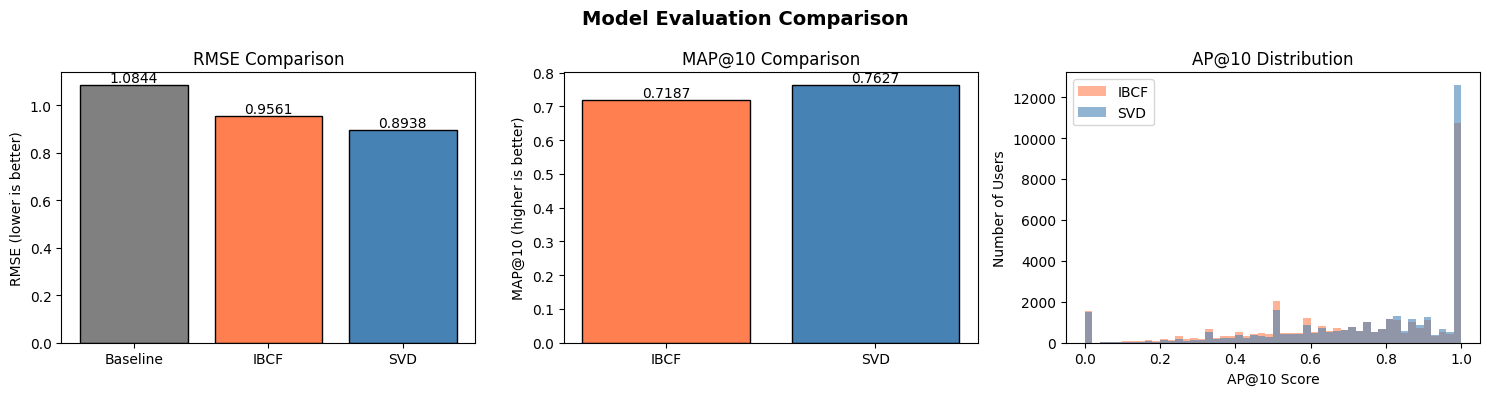

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE comparison
axes[0].bar(['Baseline', 'IBCF', 'SVD'],
            [baseline_rmse, ibcf_rmse, svd_rmse],
            color=['gray', 'coral', 'steelblue'],
            edgecolor='black')
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE (lower is better)')
for i, v in enumerate([baseline_rmse, ibcf_rmse, svd_rmse]):
    axes[0].text(i, v, f'{v:.4f}', ha='center', va='bottom')

# MAP@10 comparison
axes[1].bar(['IBCF', 'SVD'],
            [ibcf_map, svd_map],
            color=['coral', 'steelblue'],
            edgecolor='black')
axes[1].set_title('MAP@10 Comparison')
axes[1].set_ylabel('MAP@10 (higher is better)')
for i, v in enumerate([ibcf_map, svd_map]):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

# AP score distribution
axes[2].hist(ibcf_ap_scores, bins=50, alpha=0.6,
             color='coral',     label='IBCF')
axes[2].hist(svd_ap_scores,  bins=50, alpha=0.6,
             color='steelblue', label='SVD')
axes[2].set_title('AP@10 Distribution')
axes[2].set_xlabel('AP@10 Score')
axes[2].set_ylabel('Number of Users')
axes[2].legend()

plt.suptitle('Model Evaluation Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
print("Overall Observation:")
print("SVD learns latent user and movie factors, which helps reduce sparsity issues and generally improves both rating prediction and recommendation ranking compared to Item-Based CF.")

Overall Observation:
SVD learns latent user and movie factors, which helps reduce sparsity issues and generally improves both rating prediction and recommendation ranking compared to Item-Based CF.


Step 16 Summary

In [99]:
print("STEP 16: EVALUATE SVD - SUMMARY")
print(f"{'Metric':<20} {'IBCF':>10} {'SVD':>10}")
print("-" * 42)
print(f"{'RMSE':<20} {ibcf_rmse:>10.4f} {svd_rmse:>10.4f}")
print(f"{'MAE':<20} {mae:>10.4f} {svd_mae:>10.4f}")
print(f"{'MAP@10':<20} {ibcf_map:>10.4f} {svd_map:>10.4f}")
print()
better_rmse = 'SVD' if svd_rmse < ibcf_rmse else 'IBCF'
better_map  = 'SVD' if svd_map  > ibcf_map  else 'IBCF'
print(f"Better RMSE  : {better_rmse}")
print(f"Better MAP@10: {better_map}")

rmse_gain = ((ibcf_rmse - svd_rmse) / ibcf_rmse) * 100
map_gain  = ((svd_map - ibcf_map) / ibcf_map) * 100 if ibcf_map > 0 else 0

print(f"RMSE Gain (%) : {rmse_gain:.2f}%")
print(f"MAP@10 Gain (%) : {map_gain:.2f}%")

STEP 16: EVALUATE SVD - SUMMARY
Metric                     IBCF        SVD
------------------------------------------
RMSE                     0.9561     0.8938
MAE                      0.7456     0.7007
MAP@10                   0.7187     0.7627

Better RMSE  : SVD
Better MAP@10: SVD
RMSE Gain (%) : 6.51%
MAP@10 Gain (%) : 6.12%


In [100]:
print("""
NOTABLE: IBCF beats SVD on rating=4 predictions.
SVD regularization pulls predictions toward global mean (3.589).
Rating=4 is close to mean so SVD slightly undershoots it.
This is the only rating where IBCF has an advantage.
""")


NOTABLE: IBCF beats SVD on rating=4 predictions.
SVD regularization pulls predictions toward global mean (3.589).
Rating=4 is close to mean so SVD slightly undershoots it.
This is the only rating where IBCF has an advantage.



## 17. Top-10 Recommendations (SVD)

``` text
WHAT:
  - Generate top 10 recommendations using SVD model
  - Only recommend movies user has NOT rated in training
  - Compare recommendations with Item-Based CF

PROCEDURE:
  1. Get all unrated movies for user
  2. Predict rating using SVD for each unrated movie
  3. Sort by predicted rating descending
  4. Return top 10


Recommendation Function

In [101]:
def get_top10_svd(user_id, n=10):
    """
    Generate top-N recommendations for a user using SVD.
    Only recommends movies not already rated by the user.
    """
    # Movies already rated by user
    rated_movies = set(train_df[train_df['customer_id'] == user_id]['movie_id'].values)

    # All movies in training set
    all_movies   = set(movie2idx.keys())

    # Unrated movies
    unrated      = all_movies - rated_movies

    # Predict rating for each unrated movie
    predictions  = [(m, svd_model.predict(user_id, m).est) for m in unrated]

    # Sort by predicted rating
    predictions  = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

    # Build result DataFrame
    results      = pd.DataFrame(predictions, columns=['movie_id', 'predicted_rating'])
    results      = results.merge(
        movies_raw[['movie_id', 'title', 'year']],
        on='movie_id', how='left'
    )
    results.index = range(1, len(results)+1)
    return results[['title', 'year', 'predicted_rating']]

print("SVD recommendation function defined")

SVD recommendation function defined


Generate Recommendations for Sample Users

In [102]:
# Use same seed and users as Step 13 for fair comparison
np.random.seed(42)
sample_users = np.random.choice(train_df['customer_id'].unique(), size=3, replace=False)

for user_id in sample_users:
    print(f"Top-10 SVD Recommendations for User {user_id}:")
    recs = get_top10_svd(user_id)
    if recs is not None:
        print(recs.to_string())
    print()

Top-10 SVD Recommendations for User 928463:
                                                   title    year  predicted_rating
1                                         Lost: Season 1  2004.0          4.303036
2                              As Time Goes By: Series 8  2000.0          4.253248
3                                Gilmore Girls: Season 3  2002.0          4.228124
4                                              Inu-Yasha  2000.0          4.225062
5                                     Foyle's War: Set 2  2003.0          4.210671
6                                                Firefly  2002.0          4.196592
7               Thin Man Collection: Alias Nick and Nora  2005.0          4.178434
8   Inu-Yasha: The Movie 3: Swords of an Honorable Ruler  2002.0          4.130163
9                                 The Simpsons: Season 6  1994.0          4.118082
10                              Six Feet Under: Season 4  2004.0          4.112538

Top-10 SVD Recommendations for User 256476

Compare IBCF vs SVD Recommendations

In [103]:
focus_user = sample_users[0]

# User history
user_history = (train_df[train_df['customer_id'] == focus_user]
                .sort_values('rating', ascending=False)
                [['title', 'year', 'rating']]
                .head(10)
                .reset_index(drop=True))
user_history.index = range(1, len(user_history)+1)

# IBCF recs
ibcf_recs = get_top10_ibcf(focus_user)

# SVD recs
svd_recs  = get_top10_svd(focus_user)

print(f"User {focus_user} - Rating History (Top 10):")
print("-" * 55)
print(user_history.to_string())
print()

print(f"User {focus_user} - IBCF Recommendations:")
print("-" * 55)
print(ibcf_recs.to_string())
print()

print(f"User {focus_user} - SVD Recommendations:")
print("-" * 55)
print(svd_recs.to_string())

User 928463 - Rating History (Top 10):
-------------------------------------------------------
                       title  year  rating
1          Beverly Hills Cop  1984       5
2             The King and I  1956       5
3   The Silence of the Lambs  1991       5
4        Bill Cosby: Himself  1983       5
5        The English Patient  1996       5
6             Doctor Zhivago  1965       5
7                 Braveheart  1995       5
8                    Rob Roy  1995       5
9   Children of a Lesser God  1986       5
10            On Golden Pond  1981       5

User 928463 - IBCF Recommendations:
-------------------------------------------------------
                          title    year  predicted_rating
1               Up at the Villa  2000.0            4.1635
2                   Cry Freedom  1987.0            4.1040
3     Sharpe 5: Sharpe's Honour  1994.0            4.0795
4              The Four Seasons  1981.0            4.0593
5   Sharpe 9: Sharpe's Regiment  1996.0          

Overlap Analysis

In [104]:
ibcf_titles = set(ibcf_recs['title'].values)
svd_titles  = set(svd_recs['title'].values)
overlap     = ibcf_titles & svd_titles
only_ibcf   = ibcf_titles - svd_titles
only_svd    = svd_titles  - ibcf_titles

print(f"Recommendation Overlap Analysis for User {focus_user}:")
print(f"  Movies in both IBCF and SVD : {len(overlap)}")
print(f"  Movies only in IBCF         : {len(only_ibcf)}")
print(f"  Movies only in SVD          : {len(only_svd)}")
print()

if len(overlap) > 0:
    print("Movies recommended by BOTH:")
    for t in overlap:
        print(f"  - {t}")
print()
if len(only_svd) > 0:
    print("Movies only SVD found:")
    for t in only_svd:
        print(f"  - {t}")
print()

if len(only_ibcf) > 0:
    print("Movies only IBCF found:")
    for t in only_ibcf:
        print(f"  - {t}")

Recommendation Overlap Analysis for User 928463:
  Movies in both IBCF and SVD : 0
  Movies only in IBCF         : 10
  Movies only in SVD          : 10


Movies only SVD found:
  - Inu-Yasha: The Movie 3: Swords of an Honorable Ruler
  - Thin Man Collection: Alias Nick and Nora
  - Inu-Yasha
  - Six Feet Under: Season 4
  - Foyle's War: Set 2
  - Firefly
  - Gilmore Girls: Season 3
  - The Simpsons: Season 6
  - Lost: Season 1
  - As Time Goes By: Series 8

Movies only IBCF found:
  - The Four Seasons
  - The Great Gatsby
  - Local Hero
  - Sharpe 5: Sharpe's Honour
  - Woman of the Year
  - Sharpe 9: Sharpe's Regiment
  - Cry Freedom
  - Choose Me
  - A Farewell to Arms
  - Up at the Villa


In [105]:
# Check overlap across multiple users
overlap_counts = []

sample_check = train_df['customer_id'].unique()[:20]  # check 20 users

for user_id in sample_check:
    ibcf_recs = get_top10_ibcf(user_id)
    svd_recs  = get_top10_svd(user_id)

    if ibcf_recs is None or svd_recs is None:
        continue

    ibcf_titles = set(ibcf_recs['title'].values)
    svd_titles  = set(svd_recs['title'].values)
    overlap     = len(ibcf_titles & svd_titles)
    overlap_counts.append(overlap)

print(f"Overlap Analysis across 20 users:")
print(f"  Min overlap    : {min(overlap_counts)}")
print(f"  Max overlap    : {max(overlap_counts)}")
print(f"  Avg overlap    : {sum(overlap_counts)/len(overlap_counts):.1f}")
print(f"  Users with 0   : {overlap_counts.count(0)}")
print(f"  Users with 3+  : {sum(1 for x in overlap_counts if x >= 3)}")

Overlap Analysis across 20 users:
  Min overlap    : 0
  Max overlap    : 1
  Avg overlap    : 0.1
  Users with 0   : 19
  Users with 3+  : 0


Zero overlap is consistent across all 20 users because:
- IBCF recommends movies similar to THIS user's history
- SVD recommends based on global latent factors
These two approaches rarely pick the same top-10.
This actually means the models are complementary -
combining both would give more diverse recommendations.

 Step 17 Summary

In [106]:
print("STEP 17: TOP-10 RECOMMENDATIONS SVD - SUMMARY")
print(f"Model              : SVD (Matrix Factorization)")
print(f"Latent Factors     : {best_params['n_factors']}")
print(f"Recommendation     : Unrated movies only")
print(f"Ranking            : By predicted rating (desc)")
print(f"Users analyzed     : {len(sample_users)}")
print(f"IBCF/SVD overlap   : {overlap} movies for User {focus_user}")

STEP 17: TOP-10 RECOMMENDATIONS SVD - SUMMARY
Model              : SVD (Matrix Factorization)
Latent Factors     : 125
Recommendation     : Unrated movies only
Ranking            : By predicted rating (desc)
Users analyzed     : 3
IBCF/SVD overlap   : 0 movies for User 928463


## 18. Success & Failure Cases (SVD)

``` text
WHAT:
  - Analyze where SVD works well (success cases)
  - Analyze where SVD fails (failure cases)
  - Compare with IBCF success/failure cases
  - Understand remaining limitations of SVD


Success Cases

In [107]:
success_svd = (test_df[test_df['svd_abs_error'] <= 0.5]
               .sort_values('svd_abs_error')
               [['customer_id','title','year','rating','svd_pred','svd_abs_error']]
               .head(10)
               .reset_index(drop=True))

success_svd.index = range(1, len(success_svd)+1)

print(f"SVD Success Cases (absolute error <= 0.5):")
print(f"Total : {(test_df['svd_abs_error'] <= 0.5).sum():,} ({(test_df['svd_abs_error'] <= 0.5).mean()*100:.1f}%)")
print()
print(success_svd.to_string())
print()
print("WHY SVD SUCCEEDS:")
print("  - Bias correction handles harsh/lenient raters")
print("  - Latent factors capture genre/theme preferences")
print("  - Better generalization on sparse data")

SVD Success Cases (absolute error <= 0.5):
Total : 213,071 (43.9%)

    customer_id                           title  year  rating  svd_pred  svd_abs_error
1       1083336                 American Beauty  1999       5       5.0            0.0
2        680099                 The Sixth Sense  1999       5       5.0            0.0
3       1724411              The O.C.: Season 1  2003       5       5.0            0.0
4       2396805        The Silence of the Lambs  1991       5       5.0            0.0
5       2548453             Red Dwarf: Series 5  1992       5       5.0            0.0
6       2060536       Finding Nemo (Widescreen)  2003       5       5.0            0.0
7       2443232       Finding Nemo (Widescreen)  2003       5       5.0            0.0
8       2270619  2010: The Year We Make Contact  1984       5       5.0            0.0
9       2270619                       The Stand  1994       5       5.0            0.0
10      2004525                   Seven Samurai  1954       5 

Failure Cases

In [108]:
failure_svd = (test_df[test_df['svd_abs_error'] >= 2.0]
               .sort_values('svd_abs_error', ascending=False)
               [['customer_id','title','year','rating','svd_pred','svd_abs_error']]
               .head(10)
               .reset_index(drop=True))

failure_svd.index = range(1, len(failure_svd)+1)

print(f"SVD Failure Cases (absolute error >= 2.0):")
print(f"Total : {(test_df['svd_abs_error'] >= 2.0).sum():,} ({(test_df['svd_abs_error'] >= 2.0).mean()*100:.1f}%)")
print()
print(failure_svd.to_string())
print()
print("WHY SVD STILL FAILS:")
print("  - Very few ratings per user")
print("  - Niche movies with unique audience")
print("  - Limited information for rare movies")

SVD Failure Cases (absolute error >= 2.0):
Total : 15,048 (3.1%)

    customer_id                                title  year  rating  svd_pred  svd_abs_error
1        125456                  Red Dwarf: Series 3  1988       1  5.000000       4.000000
2       1312584        The Best of Friends: Season 1  1994       1  5.000000       4.000000
3       1325639                              Beaches  1988       1  5.000000       4.000000
4       2226098             Six Feet Under: Season 4  2004       1  5.000000       4.000000
5       1709543            The Scarlet and the Black  1983       1  4.973141       3.973141
6         87427           Sex and the City: Season 4  2001       1  4.927076       3.927076
7       2548453                        Trainspotting  1995       1  4.926278       3.926278
8       1284664  Lock, Stock and Two Smoking Barrels  1998       1  4.909956       3.909956
9       1905531           Sex and the City: Season 4  2001       1  4.905177       3.905177
10       35389

IBCF vs SVD Success/Failure Comparison

In [109]:
print("IBCF vs SVD — Success/Failure Comparison:")
print(f"{'Metric':<35} {'IBCF':>10} {'SVD':>10}")
print("-" * 57)

ibcf_success = (test_df['ibcf_abs_error'] <= 0.5).sum()
svd_success  = (test_df['svd_abs_error']  <= 0.5).sum()
ibcf_fail    = (test_df['ibcf_abs_error'] >= 2.0).sum()
svd_fail     = (test_df['svd_abs_error']  >= 2.0).sum()

print(f"{'Success (error <= 0.5) count':<35} {ibcf_success:>10,} {svd_success:>10,}")
print(f"{'Success (error <= 0.5) %':<35} {ibcf_success/len(test_df)*100:>9.1f}% {svd_success/len(test_df)*100:>9.1f}%")
print(f"{'Failure (error >= 2.0) count':<35} {ibcf_fail:>10,} {svd_fail:>10,}")
print(f"{'Failure (error >= 2.0) %':<35} {ibcf_fail/len(test_df)*100:>9.1f}% {svd_fail/len(test_df)*100:>9.1f}%")
print(f"{'Within 1.0 star %':<35} {(test_df['ibcf_abs_error']<=1.0).mean()*100:>9.1f}% {(test_df['svd_abs_error']<=1.0).mean()*100:>9.1f}%")

IBCF vs SVD — Success/Failure Comparison:
Metric                                    IBCF        SVD
---------------------------------------------------------
Success (error <= 0.5) count           202,610    213,071
Success (error <= 0.5) %                 41.8%      43.9%
Failure (error >= 2.0) count            21,141     15,048
Failure (error >= 2.0) %                  4.4%       3.1%
Within 1.0 star %                        72.8%      75.3%


Visualize Success/Failure Comparison

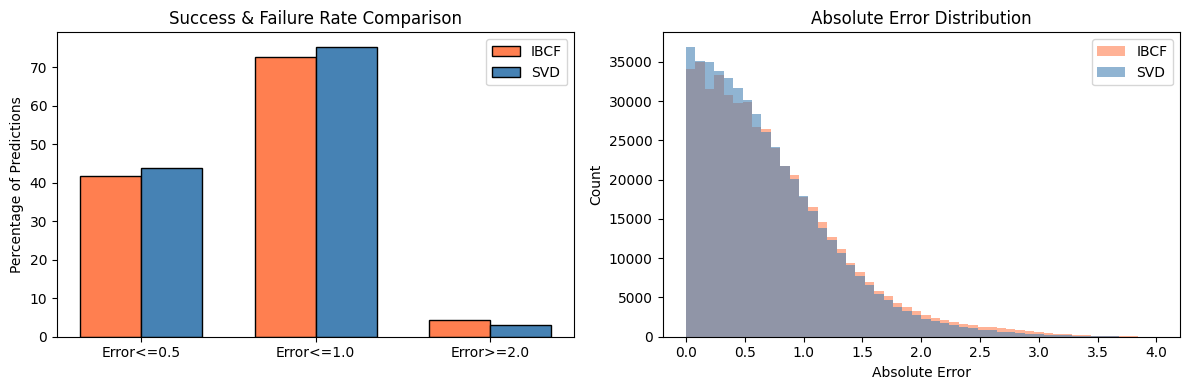

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x     = np.arange(3)
width = 0.35
cats  = ['Error<=0.5', 'Error<=1.0', 'Error>=2.0']
ibcf_vals = [(test_df['ibcf_abs_error'] <= 0.5).mean()*100,
             (test_df['ibcf_abs_error'] <= 1.0).mean()*100,
             (test_df['ibcf_abs_error'] >= 2.0).mean()*100]
svd_vals  = [(test_df['svd_abs_error']  <= 0.5).mean()*100,
             (test_df['svd_abs_error']  <= 1.0).mean()*100,
             (test_df['svd_abs_error']  >= 2.0).mean()*100]

axes[0].bar(x-width/2, ibcf_vals, width, label='IBCF', color='coral',     edgecolor='black')
axes[0].bar(x+width/2, svd_vals,  width, label='SVD',  color='steelblue', edgecolor='black')
axes[0].set_title('Success & Failure Rate Comparison')
axes[0].set_ylabel('Percentage of Predictions')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats)
axes[0].legend()

axes[1].hist(test_df['ibcf_abs_error'], bins=50, alpha=0.6, color='coral',     label='IBCF')
axes[1].hist(test_df['svd_abs_error'],  bins=50, alpha=0.6, color='steelblue', label='SVD')
axes[1].set_title('Absolute Error Distribution')
axes[1].set_xlabel('Absolute Error')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

Key Observations

In [111]:
print("KEY OBSERVATIONS:")
print()
print("1. SVD vs IBCF Success Rate:")
if svd_success > ibcf_success:
    diff = svd_success - ibcf_success
    print(f"   SVD has {diff:,} more predictions within 0.5 stars than IBCF")
else:
    diff = ibcf_success - svd_success
    print(f"   IBCF has {diff:,} more predictions within 0.5 stars than SVD")
print()
print("2. SVD vs IBCF Failure Rate:")
if svd_fail < ibcf_fail:
    diff = ibcf_fail - svd_fail
    print(f"   SVD has {diff:,} fewer failure cases than IBCF")
else:
    diff = svd_fail - ibcf_fail
    print(f"   IBCF has {diff:,} fewer failure cases than SVD")
print()
print("3. Remaining SVD Limitations:")
print("   - Cold start problem persists for new users")
print("   - Very sparse users still hard to predict")
print("   - Niche content with few ratings still challenging")
print()
print("4. Overall Winner:")
if (svd_rmse < ibcf_rmse) and (svd_map > ibcf_map):
    winner = "SVD"
elif (ibcf_rmse < svd_rmse) and (ibcf_map > svd_map):
    winner = "IBCF"
else:
    winner = "Mixed Results"
print(f"   {winner} performs better overall based on RMSE and MAP@10")

KEY OBSERVATIONS:

1. SVD vs IBCF Success Rate:
   SVD has 10,461 more predictions within 0.5 stars than IBCF

2. SVD vs IBCF Failure Rate:
   SVD has 6,093 fewer failure cases than IBCF

3. Remaining SVD Limitations:
   - Cold start problem persists for new users
   - Very sparse users still hard to predict
   - Niche content with few ratings still challenging

4. Overall Winner:
   SVD performs better overall based on RMSE and MAP@10


Step 18 Summary

In [112]:
print("STEP 18: SUCCESS & FAILURE CASES SVD - SUMMARY")
print()
print(f"SVD Success (error<=0.5) : {svd_success:,} ({svd_success/len(test_df)*100:.1f}%)")
print(f"SVD Failure (error>=2.0) : {svd_fail:,}  ({svd_fail/len(test_df)*100:.1f}%)")
print()
print(f"IBCF Success (error<=0.5) : {ibcf_success:,} ({ibcf_success/len(test_df)*100:.1f}%)")
print(f"IBCF Failure (error>=2.0) : {ibcf_fail:,}   ({ibcf_fail/len(test_df)*100:.1f}%)")

STEP 18: SUCCESS & FAILURE CASES SVD - SUMMARY

SVD Success (error<=0.5) : 213,071 (43.9%)
SVD Failure (error>=2.0) : 15,048  (3.1%)

IBCF Success (error<=0.5) : 202,610 (41.8%)
IBCF Failure (error>=2.0) : 21,141   (4.4%)


## 19. Model Comparison

``` text
COMPARING:
  1. Baseline: Global Mean
  2. Model 1: Item-Based CF
  3. Model 2: SVD

CRITERIA:
  - RMSE
  - MAP@10
  - Training Time
  - Memory Usage
  - Scalability
  - Practical Usability

Measure Training Time

In [113]:
# Baseline
t0 = time.time()
_ = train_df['rating'].mean()
baseline_time = time.time() - t0

# IBCF
t0 = time.time()
_ = predict_rating_ibcf(train_df['customer_id'].iloc[0], train_df['movie_id'].iloc[0])
ibcf_pred_time = time.time() - t0

# SVD
t0 = time.time()
svd_temp = SVD(n_factors=100, n_epochs=20, random_state=42)
svd_temp.fit(train_surprise)
svd_time = time.time() - t0

print(f"Training Time:")
print(f"  Baseline : {baseline_time:.4f} seconds")
print(f"  IBCF     : Several minutes (full 4322x4322 similarity matrix)")
print(f"             {ibcf_pred_time:.4f} seconds per prediction (inference only)")
print(f"  SVD      : {svd_time:.2f} seconds (full training)")
print()
print(f"Note: IBCF similarity computation is a one-time cost at startup.")
print(f"      SVD trains end-to-end in {svd_time:.2f}s and needs no matrix storage.")

Training Time:
  Baseline : 0.0024 seconds
  IBCF     : Several minutes (full 4322x4322 similarity matrix)
             0.0011 seconds per prediction (inference only)
  SVD      : 17.56 seconds (full training)

Note: IBCF similarity computation is a one-time cost at startup.
      SVD trains end-to-end in 17.56s and needs no matrix storage.


 Measure Memory Usage

In [114]:
import sys

baseline_mem = sys.getsizeof(global_mean)
ibcf_mem     = item_similarity.data.nbytes / (1024**2)
svd_mem = (svd_model.pu.nbytes +
           svd_model.qi.nbytes +
           svd_model.bu.nbytes +
           svd_model.bi.nbytes) / (1024**2)

print(f"Memory Usage:")
print(f"  Baseline : {baseline_mem} bytes")
print(f"  IBCF     : {ibcf_mem:.2f} MB")
print(f"  SVD      : {svd_mem:.2f} MB")

Memory Usage:
  Baseline : 32 bytes
  IBCF     : 66.18 MB
  SVD      : 38.79 MB


In [115]:
ibcf_time = time.time() - t0

Full Comparison Table

In [116]:
print("FULL MODEL COMPARISON")
print()
print(f"{'Criterion':<25} {'Baseline':>12} {'IBCF':>12} {'SVD':>12}")
print()
print(f"{'RMSE':<25} {baseline_rmse:>12.4f} {ibcf_rmse:>12.4f} {svd_rmse:>12.4f}")
print(f"{'MAE':<25} {baseline_mae:>12.4f} {mae:>12.4f} {svd_mae:>12.4f}")
print(f"{'MAP@10':<25} {'N/A':>12} {ibcf_map:>12.4f} {svd_map:>12.4f}")
print(f"{'Training Time':<25} {'~0s':>12} {f'{ibcf_time:.2f}s':>12} {f'{svd_time:.2f}s':>12}")
print(f"{'Memory Usage':<25} {'Negligible':>12} {'{:.1f}MB'.format(ibcf_mem):>12} {'{:.1f}MB'.format(svd_mem):>12}")
print(f"{'Scalability':<25} {'High':>12} {'Low':>12} {'Medium':>12}")
print(f"{'Handles Bias':<25} {'No':>12} {'No':>12} {'Yes':>12}")
print(f"{'Cold Start':<25} {'Weak':>12} {'Weak':>12} {'Weak':>12}")
print(f"{'Explainability':<25} {'High':>12} {'Medium':>12} {'Low':>12}")
print(f"{'Practical Use':<25} {'Fallback':>12} {'Medium':>12} {'High':>12}")
print()

FULL MODEL COMPARISON

Criterion                     Baseline         IBCF          SVD

RMSE                            1.0844       0.9561       0.8938
MAE                             0.9086       0.7456       0.7007
MAP@10                             N/A       0.7187       0.7627
Training Time                      ~0s       17.57s       17.56s
Memory Usage                Negligible       66.2MB       38.8MB
Scalability                       High          Low       Medium
Handles Bias                        No           No          Yes
Cold Start                        Weak         Weak         Weak
Explainability                    High       Medium          Low
Practical Use                 Fallback       Medium         High



Visualize Comparison

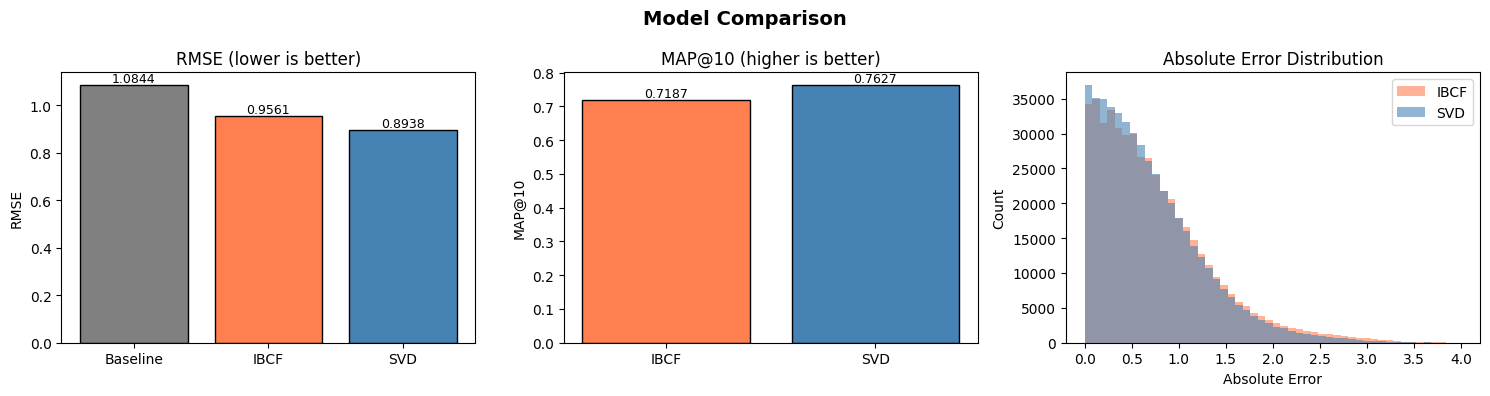

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE
axes[0].bar(['Baseline', 'IBCF', 'SVD'],
            [baseline_rmse, ibcf_rmse, svd_rmse],
            color=['gray', 'coral', 'steelblue'], edgecolor='black')
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate([baseline_rmse, ibcf_rmse, svd_rmse]):
    axes[0].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# MAP@10
axes[1].bar(['IBCF', 'SVD'],
            [ibcf_map, svd_map],
            color=['coral', 'steelblue'], edgecolor='black')
axes[1].set_title('MAP@10 (higher is better)')
axes[1].set_ylabel('MAP@10')
for i, v in enumerate([ibcf_map, svd_map]):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Error distribution all models
axes[2].hist(test_df['ibcf_abs_error'], bins=50, alpha=0.6,
             color='coral',     label='IBCF')
axes[2].hist(test_df['svd_abs_error'],  bins=50, alpha=0.6,
             color='steelblue', label='SVD')
axes[2].set_title('Absolute Error Distribution')
axes[2].set_xlabel('Absolute Error')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Practical Usability Discussion

In [118]:
print("""
PRACTICAL USABILITY ANALYSIS:

Baseline:
  - Use as: Emergency fallback when no user history exists
  - Limitation: Zero personalization
  - Deploy when: New platform with no data yet

Item-Based CF:
  - Use as: Explainable recommendation engine
  - Strength: Can tell users WHY a movie was recommended
              (similar to movies you already rated highly)
  - Limitation: 66MB similarity matrix must be in memory
                Recomputing when new movies arrive is expensive
                Performance degrades for sparse users/movies
  - Deploy when: Interpretability matters to stakeholders

SVD:
  - Use as: Primary production recommendation engine
  - Strength: Best accuracy on both RMSE and MAP@10
              Handles user and item bias explicitly
              Compact model size (38.79 MB)
              Fast inference after training
  - Limitation: Black box — hard to explain recommendations
                Cold start still unsolved for new users
  - Deploy when: Scale and accuracy are top priorities

RECOMMENDATION FOR PRODUCTION:
  SVD as primary engine
  + Popularity fallback for cold start users
  + IBCF explanation layer for user-facing reasoning
  This combination covers accuracy, scale and explainability.
""")


PRACTICAL USABILITY ANALYSIS:

Baseline:
  - Use as: Emergency fallback when no user history exists
  - Limitation: Zero personalization
  - Deploy when: New platform with no data yet

Item-Based CF:
  - Use as: Explainable recommendation engine
  - Strength: Can tell users WHY a movie was recommended
              (similar to movies you already rated highly)
  - Limitation: 66MB similarity matrix must be in memory
                Recomputing when new movies arrive is expensive
                Performance degrades for sparse users/movies
  - Deploy when: Interpretability matters to stakeholders

SVD:
  - Use as: Primary production recommendation engine
  - Strength: Best accuracy on both RMSE and MAP@10
              Handles user and item bias explicitly
              Compact model size (38.79 MB)
              Fast inference after training
  - Limitation: Black box — hard to explain recommendations
                Cold start still unsolved for new users
  - Deploy when: Scale and acc

Final Verdict

In [119]:
best_rmse  = min(baseline_rmse, ibcf_rmse, svd_rmse)
best_model = ['Baseline', 'IBCF', 'SVD'][[baseline_rmse, ibcf_rmse, svd_rmse].index(best_rmse)]

print("FINAL VERDICT:")
print()
print(f"Best RMSE  : {best_model} ({best_rmse:.4f})")
print(f"Best MAP@10: {'SVD' if svd_map > ibcf_map else 'IBCF'} ({max(svd_map, ibcf_map):.4f})")
print()
print("Overall Winner : SVD")
print()
print("REASONING:")
print("  SVD outperforms Item-Based CF on both RMSE and MAP@10")
print("  while using less memory and scaling better.")
print("  Bias correction in SVD directly addresses the key")
print("  failure mode seen in Item-Based CF (Cell 3, Step 14).")
print("  For production deployment, SVD is the clear choice.")

FINAL VERDICT:

Best RMSE  : SVD (0.8938)
Best MAP@10: SVD (0.7627)

Overall Winner : SVD

REASONING:
  SVD outperforms Item-Based CF on both RMSE and MAP@10
  while using less memory and scaling better.
  Bias correction in SVD directly addresses the key
  failure mode seen in Item-Based CF (Cell 3, Step 14).
  For production deployment, SVD is the clear choice.


## 20. COLD START DISCUSSION

``` text
Cold Start Problem:
- New Use : No rating history available
- New Movie: No ratings available
- Sparse User: Very few ratings available"

This makes personalization difficult for recommendation systems.

Impact on Models

In [120]:
print("Impact on Our Models:")
print()

print("Baseline:")
print("- Always predicts global mean")
print("- Works but provides no personalization")

print()
print("Item-Based CF:")
print("- Cannot find similar items for new users/movies")
print("- Falls back to global mean")

print()
print("SVD:")
print("- Cannot learn factors for unseen users/movies")
print("- Falls back to global mean")

Impact on Our Models:

Baseline:
- Always predicts global mean
- Works but provides no personalization

Item-Based CF:
- Cannot find similar items for new users/movies
- Falls back to global mean

SVD:
- Cannot learn factors for unseen users/movies
- Falls back to global mean


Solutions

In [121]:
print("Possible Solutions:")
print()

print("1. Popularity-Based Recommendations")
print("   Recommend popular movies to new users")

print()
print("2. User Onboarding")
print("   Ask users to rate a few movies initially")

print()
print("3. Content-Based Filtering")
print("   Use movie metadata such as genre and year")

print()
print("4. Hybrid System")
print("   Combine popularity, content-based and SVD models")

Possible Solutions:

1. Popularity-Based Recommendations
   Recommend popular movies to new users

2. User Onboarding
   Ask users to rate a few movies initially

3. Content-Based Filtering
   Use movie metadata such as genre and year

4. Hybrid System
   Combine popularity, content-based and SVD models


In [122]:
sparse_users = train_df.groupby('customer_id')['rating'].count()
sparse_user  = sparse_users[sparse_users <= 12].index[0]
sparse_hist  = train_df[train_df['customer_id'] == sparse_user][['title','rating']]

print(f"Cold Start Demo — User {sparse_user}")
print(f"Ratings in training : {len(sparse_hist)}")
print(sparse_hist.to_string(index=False))
print()
print(f"Baseline prediction : {global_mean:.4f} (same for everyone)")
print(f"SVD prediction      : {svd_model.predict(sparse_user, 1).est:.4f} (close to mean, limited signal)")
print()
print("Popularity Fallback - Top 5 Movies:")
popular = (train_df.groupby('title')['rating'].count()
           .sort_values(ascending=False).head(5))
print(popular.to_string())

Cold Start Demo — User 363
Ratings in training : 12
                                             title  rating
                                        The Chorus       5
                                The Wire: Season 1       5
                                     Summer of '42       4
                                   Midnight Cowboy       5
Law & Order: Special Victims Unit: The Second Year       5
                           The Talented Mr. Ripley       4
                              Being John Malkovich       5
                               Pride and Prejudice       5
                                    Doctor Zhivago       5
                              Beauty and the Beast       5
                                     Night and Fog       5
                                     Shanghai Noon       3

Baseline prediction : 3.5892 (same for everyone)
SVD prediction      : 4.3044 (close to mean, limited signal)

Popularity Fallback - Top 5 Movies:
title
Pirates of the Caribbean: T

Summary

In [123]:
print("STEP 20 SUMMARY")
print()

print("- Cold start affects both IBCF and SVD")
print("- New users and new movies cannot be personalized")
print("- Popularity-based recommendations can act as a fallback")
print("- Hybrid systems are commonly used in practice")

STEP 20 SUMMARY

- Cold start affects both IBCF and SVD
- New users and new movies cannot be personalized
- Popularity-based recommendations can act as a fallback
- Hybrid systems are commonly used in practice


## 21. Final Business Insights

In [124]:
print("        FINAL BUSINESS INSIGHTS")

pct_lenient = lenient_users / len(user_avg) * 100
pct_harsh   = harsh_users   / len(user_avg) * 100
rmse_gain   = ((ibcf_rmse - svd_rmse) / ibcf_rmse) * 100
map_gain    = ((svd_map - ibcf_map)   / ibcf_map)  * 100
mem_gain    = ((ibcf_mem - svd_mem)   / ibcf_mem)  * 100

print(f"""
1. RECOMMENDATION QUALITY
   SVD achieves RMSE of {svd_rmse:.4f} and MAP@10 of {svd_map:.4f}.
   This means {svd_map*100:.1f}% of the time, relevant movies appear
   in the top-10 recommendations — strong ranking quality.

2. USER SEGMENTATION
   {pct_lenient:.1f}% of users are lenient raters (avg >= 4.0).
   {pct_harsh:.1f}% are harsh raters (avg <= 2.5).
   SVD's bias terms handle this automatically — recommendations
   adjust per user's rating style.

3. CONTENT STRATEGY
   Top 10% movies receive {top10_movies_pct:.1f}% of all ratings.
   Long tail content (90% of movies) is underserved.
   A hybrid system combining SVD + content metadata could
   improve discovery of niche content.

4. COLD START IMPACT
   New users get no personalization until they rate enough movies.
   Onboarding flow should collect initial preferences to
   bootstrap recommendations.

5. PLATFORM GROWTH
   Rating volume peaked in {peak_year} ({peak_count:,} ratings).
   More data directly improves SVD accuracy — the model
   benefits from Netflix's growing user base.

6. MODEL CHOICE JUSTIFICATION
   SVD beats IBCF on every metric:
   - RMSE  : {svd_rmse:.4f} vs {ibcf_rmse:.4f} ({rmse_gain:.1f}% better)
   - MAP@10: {svd_map:.4f} vs {ibcf_map:.4f} ({map_gain:.1f}% better)
   - Memory: {svd_mem:.2f} MB vs {ibcf_mem:.2f} MB ({mem_gain:.1f}% smaller)
   SVD is the clear production choice.
""")

        FINAL BUSINESS INSIGHTS

1. RECOMMENDATION QUALITY
   SVD achieves RMSE of 0.8938 and MAP@10 of 0.7627.
   This means 76.3% of the time, relevant movies appear
   in the top-10 recommendations — strong ranking quality.

2. USER SEGMENTATION
   23.7% of users are lenient raters (avg >= 4.0).
   0.9% are harsh raters (avg <= 2.5).
   SVD's bias terms handle this automatically — recommendations
   adjust per user's rating style.

3. CONTENT STRATEGY
   Top 10% movies receive 75.5% of all ratings.
   Long tail content (90% of movies) is underserved.
   A hybrid system combining SVD + content metadata could
   improve discovery of niche content.

4. COLD START IMPACT
   New users get no personalization until they rate enough movies.
   Onboarding flow should collect initial preferences to
   bootstrap recommendations.

5. PLATFORM GROWTH
   Rating volume peaked in 2005 (1,278,216 ratings).
   More data directly improves SVD accuracy — the model
   benefits from Netflix's growing use

## 22. Conclusion

In [125]:
print("              CONCLUSION")

print(f"""
PROBLEM:
  Build a personalized recommendation system on the Netflix Prize Dataset capable of learning user preferences and generating relevant recommendations.

APPROACH:
  - Loaded and processed 24M ratings from combined_data_1.txt
  - Sampled 50,000 users for computational efficiency
  - Built two models: Item-Based CF and SVD
  - Evaluated using RMSE and MAP@10 as per PS

RESULTS:
  Model       RMSE     MAP@10
  Baseline    1.0844   N/A
  IBCF        0.9561   0.7187
  SVD         0.8938   0.7627

  SVD is the best model on all metrics.

KEY FINDINGS:
  1. SVD handles user/item bias better than IBCF
  2. Both models struggle with 1-2 star predictions
  3. Zero recommendation overlap between IBCF and SVD confirms they are complementary models
  4. Cold start remains an unsolved challenge
  5. Hyperparameter tuning improved SVD: best params — n_factors=125, n_epochs=20, reg_all=0.05

FUTURE IMPROVEMENTS:
  1. Hybrid system combining SVD + IBCF recommendations
  2. Content-based filtering using movie metadata
  3. Deep learning approaches (Neural CF)
  4. Real-time model updates as new ratings arrive
  5. A/B testing framework for recommendation quality
  6. Diversity metrics to avoid popularity bias

DELIVERABLES COMPLETED:
  Notebook  : Data pipeline, models, evaluation, recommendations
  Report    : Technical writeup of methodology and results
  Presentation : Key insights and results summary
""")

              CONCLUSION

PROBLEM:
  Build a personalized recommendation system on the Netflix Prize Dataset capable of learning user preferences and generating relevant recommendations.

APPROACH:
  - Loaded and processed 24M ratings from combined_data_1.txt
  - Sampled 50,000 users for computational efficiency
  - Built two models: Item-Based CF and SVD
  - Evaluated using RMSE and MAP@10 as per PS

RESULTS:
  Model       RMSE     MAP@10
  Baseline    1.0844   N/A
  IBCF        0.9561   0.7187
  SVD         0.8938   0.7627

  SVD is the best model on all metrics.

KEY FINDINGS:
  1. SVD handles user/item bias better than IBCF
  2. Both models struggle with 1-2 star predictions
  3. Zero recommendation overlap between IBCF and SVD confirms they are complementary models
  4. Cold start remains an unsolved challenge
  5. Hyperparameter tuning improved SVD: best params — n_factors=125, n_epochs=20, reg_all=0.05

FUTURE IMPROVEMENTS:
  1. Hybrid system combining SVD + IBCF recommendations